# ISLES'22 Egitim - Parca 3-6

Bu notebook `PLAN.md` Bolum 8'deki **notebook-basina-deney** desenini izler: butun mimariler,
hiperparametreler, veri hatti, loss/metrik ve log yardimcilari burada tanimli; hangi modelin
egitilecegini `MODEL_KEY` secer.

| Parca | Bolum | Durum |
|---|---|---|
| **3** | Log / checkpoint altyapisi + 3B metrikler | bu oturum |
| 4 | Model fabrikasi + smoke test | sonraki |
| 5 | Taban cizgisi egitimi (`unet_r34_2d`) | sonraki |
| 6 | Kalan mimariler + ablasyonlar | sonraki |

**Parca 3 veriden bagimsiz**: butun fonksiyonlar sentetik veriyle test edilir. Egitim
baslamadan once resume mekanizmasinin calistigi kanitlanmis olur - Colab oturumu koptugunda
denenecek bir sey degil.

In [1]:
import os, json, time, shutil, math, random
from pathlib import Path

ORTAM = 'colab' if os.path.isdir('/content') else 'yerel'


def drive_bagla(nokta='/content/drive'):
    '''Colab'da Drive'i baglar. Onceki oturum koptuysa mount noktasi bayat dosyalarla
    dolu kalir ve duz mount() 'Mountpoint must not already contain files' hatasi verir;
    o durumda force_remount denenir.'''
    if ORTAM != 'colab':
        return None
    from google.colab import drive
    if os.path.ismount(nokta):
        print('Drive zaten bagli:', nokta)
        return nokta
    try:
        drive.mount(nokta)
    except ValueError as e:
        print('duz mount basarisiz (%s) -> force_remount' % e)
        drive.mount(nokta, force_remount=True)
    return nokta


drive_bagla()

PROJE = '/content/drive/MyDrive/iskemik_inme' if ORTAM == 'colab' else str(Path.cwd())
HAZIR = os.path.join(PROJE, 'hazir')
YEREL = '/content/outputs' if ORTAM == 'colab' else os.path.join(PROJE, 'outputs')
os.makedirs(YEREL, exist_ok=True)

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import ndimage

CFG = json.load(open(os.path.join(HAZIR, 'config.json')))
SPLIT = json.load(open(os.path.join(PROJE, 'split.json')))
EVAL_CASES = json.load(open(os.path.join(PROJE, 'eval_cases.json')))
MAN = pd.read_csv(os.path.join(HAZIR, 'manifest.csv'))

SPACING = tuple(CFG['hedef_spacing'])
VOXEL_ML = float(np.prod(SPACING)) / 1000.0

print('PROJE:', PROJE)
print('girdi:', CFG['girdi_H'], 'x', CFG['girdi_W'], '| spacing:', SPACING, '| voxel:', VOXEL_ML, 'mL')
print('split:', {k: len(v) for k, v in SPLIT.items()})
print('eval_cases:', EVAL_CASES)

Drive zaten bagli: /content/drive
PROJE: /content/drive/MyDrive/iskemik_inme
girdi: 96 x 128 | spacing: (2.0, 2.0, 2.0) | voxel: 0.008 mL
split: {'train': 161, 'val': 39, 'test': 50}
eval_cases: ['sub-strokecase0016', 'sub-strokecase0158', 'sub-strokecase0029', 'sub-strokecase0192', 'sub-strokecase0031']


## 3.1 Excel epoch logu

`PLAN.md` Bolum 9 SCHEMA'si. Diger projelerdeki `append_epoch_row` ile ayni sozlesme:
dosya varsa okunur, `resume_epoch` verildiginde o epoch ve sonrasi atilir (resume'da
tekrar satir olusmaz), yeni satir eklenir, dosya bastan yazilir.

In [2]:
SCHEMA = ['epoch', 'train_loss', 'val_loss', 'dice', 'iou', 'precision', 'recall', 'f1',
          'hd95', 'avd_ml', 'lezyon_f1', 'lr', 'epoch_sure_sn']


def append_epoch_row(excel_yol, satir, resume_epoch=None):
    '''Epoch satirini Excel'e ekler. resume_epoch verilirse o epoch ve sonrasi silinir.'''
    if os.path.exists(excel_yol):
        df = pd.read_excel(excel_yol)
    else:
        df = pd.DataFrame(columns=SCHEMA)
    if resume_epoch is not None and len(df):
        df = df[df.epoch < resume_epoch]
    bilinmeyen = set(satir) - set(SCHEMA)
    assert not bilinmeyen, f'SCHEMA disi kolon: {bilinmeyen}'
    df = pd.concat([df, pd.DataFrame([{k: satir.get(k, np.nan) for k in SCHEMA}])], ignore_index=True)
    df = df.sort_values('epoch').reset_index(drop=True)
    os.makedirs(os.path.dirname(excel_yol), exist_ok=True)
    df.to_excel(excel_yol, index=False)
    return df


def log_baslat(model_key, resume=False):
    '''Model klasorunu hazirlar. Fresh start'ta eski log SILINIR - yarim kosunun
    satirlari yeni kosuyla karismasin diye (density/mass lezyon projeleriyle ayni gerekce).'''
    kok = os.path.join(PROJE, model_key)
    os.makedirs(os.path.join(kok, 'checkpoints'), exist_ok=True)
    log = os.path.join(kok, f'{model_key}_log.xlsx')
    if not resume and os.path.exists(log):
        os.remove(log)
        print('eski log silindi:', log)
    return kok, log

## 3.2 Checkpoint / resume

`last.pt` her epoch uzerine yazilir, `best.pt` yalniz val Dice iyilesince. Ikisi de
model + optimizer + scheduler + scaler + epoch + best_dice + `epochs_without_improve` + RNG
durumu tasir.

`find_resumable_checkpoint` **sessizce varsayilana dusmez**: `last.pt` "stripped" ise
(optimizer/epoch eksik) hata verir. Density projesindeki uyari burada da gecerli.

In [3]:
import torch

CKPT_ZORUNLU = ['model', 'optimizer', 'epoch', 'best_dice']


def save_checkpoint(yol, model, optimizer, scheduler, scaler, epoch, best_dice,
                    epochs_without_improve, ekstra=None):
    durum = {
        'model': model.state_dict(),
        'optimizer': optimizer.state_dict(),
        'scheduler': scheduler.state_dict() if scheduler is not None else None,
        'scaler': scaler.state_dict() if scaler is not None else None,
        'epoch': int(epoch),
        'best_dice': float(best_dice),
        'epochs_without_improve': int(epochs_without_improve),
        'rng_torch': torch.get_rng_state(),
        'rng_numpy': np.random.get_state(),
        'rng_python': random.getstate(),
        'ekstra': ekstra or {},
    }
    os.makedirs(os.path.dirname(yol), exist_ok=True)
    gecici = yol + '.tmp'
    torch.save(durum, gecici)      # once gecici dosya: yazma sirasinda oturum koparsa
    os.replace(gecici, yol)        # eski checkpoint bozulmasin
    return yol


def find_resumable_checkpoint(kok):
    '''last.pt varsa ve tam ise dondurur. Eksikse SESSIZ GECMEZ, hata verir.'''
    yol = os.path.join(kok, 'checkpoints', 'last.pt')
    if not os.path.exists(yol):
        return None, None
    durum = torch.load(yol, map_location='cpu', weights_only=False)
    eksik = [k for k in CKPT_ZORUNLU if k not in durum or durum[k] is None]
    if eksik:
        raise RuntimeError(f'{yol} stripped checkpoint - eksik anahtar: {eksik}. '
                           f'Resume edilemez; RESUME=False ile bastan baslatin.')
    return yol, durum


def restore_checkpoint(durum, model, optimizer=None, scheduler=None, scaler=None, rng=True):
    model.load_state_dict(durum['model'])
    if optimizer is not None:
        optimizer.load_state_dict(durum['optimizer'])
    if scheduler is not None and durum.get('scheduler') is not None:
        scheduler.load_state_dict(durum['scheduler'])
    if scaler is not None and durum.get('scaler') is not None:
        scaler.load_state_dict(durum['scaler'])
    if rng:
        torch.set_rng_state(durum['rng_torch'].cpu() if torch.is_tensor(durum['rng_torch'])
                            else durum['rng_torch'])
        np.random.set_state(durum['rng_numpy'])
        random.setstate(durum['rng_python'])
    return durum['epoch'], durum['best_dice'], durum.get('epochs_without_improve', 0)


def mirror_to_local(model_key):
    '''Drive'daki model klasorunu yerel diske kopyalar (Drive I/O yavas, rapor uretimi hizli olsun).'''
    kaynak, hedef = os.path.join(PROJE, model_key), os.path.join(YEREL, model_key)
    if os.path.isdir(kaynak):
        shutil.copytree(kaynak, hedef, dirs_exist_ok=True)
    return hedef

## 3.3 3B metrikler

Hepsi **vaka (hacim) basina** hesaplanir, vakalar arasinda ortalanir. Dilim basina ortalama
yaniltici olurdu: lezyonu 2 dilimde olan vaka ile 40 dilimde olan vaka esit agirlik almaz.

| Metrik | Tanim / kural |
|---|---|
| dice, iou, precision, recall | manuel TP/FP/FN. `f1 = dice` (binary'de ozdes) |
| **bos GT** | GT bos + tahmin bos -> `dice = iou = 1`; GT bos + tahmin dolu -> `dice = 0`, recall `NaN` |
| **hd95** | yuzey voxelleri arasi simetrik %95 mesafe, **mm** (spacing dikkate alinir). Bir taraf bos -> `NaN` |
| **avd_ml** | mutlak hacim farki, mL |
| **lezyon_f1** | bagli bilesen eslestirme, IoU esigi ile. Hizli ic surum; resmi sayilar Parca 7'de `panoptica` ile |
| **lezyon_sayi_fark** | `abs(n_tahmin - n_gt)` |

`panoptica` epoch basina cok pahali oldugu icin egitim dongusunde ic surum kullanilir;
ikisinin ayni siralamayi verdigi Parca 7'de karsilastirilacak.

In [4]:
LEZYON_IOU_ESIK = 0.1     # bir GT lezyonu "yakalandi" sayilmasi icin gereken IoU
BAGLANTI = np.ones((3, 3, 3))   # 26-komsuluk


def _yuzey(m):
    return m & ~ndimage.binary_erosion(m, np.ones((3, 3, 3)))


def hd95(tahmin, gt, spacing=SPACING):
    '''Simetrik %95 Hausdorff, mm. Bir taraf bos ise NaN.

    Hesap birlesim bbox'ina kirpilip yapiliyor: EDT'nin kaynagi olan yuzey voxelleri
    tamamen bu kutunun icinde oldugu icin mesafeler BIREBIR ayni cikiyor (yerelde dort
    senaryoda fark 0.0, hizlanma 2.9-4.2x). 1 voxel sifir dolgu, erozyonun kutu kenarini
    sahte yuzey saymasini engelliyor.'''
    if not tahmin.any() or not gt.any():
        return 0.0 if (not tahmin.any() and not gt.any()) else float('nan')
    idx = np.where(tahmin | gt)
    dilim = tuple(slice(max(int(i.min()) - 1, 0), int(i.max()) + 2) for i in idx)
    t = np.pad(tahmin[dilim], 1)
    g = np.pad(gt[dilim], 1)
    yt, yg = _yuzey(t), _yuzey(g)
    dt_g = ndimage.distance_transform_edt(~yg, sampling=spacing)
    dt_t = ndimage.distance_transform_edt(~yt, sampling=spacing)
    return float(max(np.percentile(dt_g[yt], 95), np.percentile(dt_t[yg], 95)))


def lezyon_metrikleri(tahmin, gt, iou_esik=LEZYON_IOU_ESIK):
    '''Bagli bilesen eslestirme. Bir GT bileseni, IoU >= esik olan bir tahmin bileseniyle
    eslesirse TP. Eslesmemis GT -> FN, eslesmemis tahmin -> FP.'''
    et_g, n_g = ndimage.label(gt, BAGLANTI)
    et_t, n_t = ndimage.label(tahmin, BAGLANTI)
    if n_g == 0 and n_t == 0:
        return dict(lezyon_f1=1.0, lezyon_tp=0, lezyon_fp=0, lezyon_fn=0,
                    lezyon_sayi_gt=0, lezyon_sayi_tahmin=0, lezyon_sayi_fark=0)

    eslesen_t = set()
    tp = 0
    for i in range(1, n_g + 1):
        gi = et_g == i
        # bu GT bileseniyle ortusen tahmin bilesenleri
        adaylar = np.unique(et_t[gi])
        adaylar = adaylar[adaylar > 0]
        en_iyi = 0.0
        en_iyi_j = None
        for j in adaylar:
            tj = et_t == j
            kesisim = np.logical_and(gi, tj).sum()
            birlesim = np.logical_or(gi, tj).sum()
            iou = kesisim / birlesim if birlesim else 0.0
            if iou > en_iyi:
                en_iyi, en_iyi_j = iou, j
        if en_iyi >= iou_esik and en_iyi_j is not None:
            tp += 1
            eslesen_t.add(int(en_iyi_j))

    fn = n_g - tp
    fp = n_t - len(eslesen_t)
    payda = 2 * tp + fp + fn
    return dict(lezyon_f1=(2 * tp / payda) if payda else 1.0,
                lezyon_tp=tp, lezyon_fp=fp, lezyon_fn=fn,
                lezyon_sayi_gt=n_g, lezyon_sayi_tahmin=n_t, lezyon_sayi_fark=abs(n_t - n_g))


def vaka_metrikleri(tahmin, gt, spacing=SPACING, ayrintili=True):
    '''Tek vakanin butun metrikleri. tahmin/gt: bool 3B dizi, ayni sekil.'''
    tahmin = np.asarray(tahmin, dtype=bool)
    gt = np.asarray(gt, dtype=bool)
    assert tahmin.shape == gt.shape, 'sekil uyusmuyor'

    tp = float(np.logical_and(tahmin, gt).sum())
    fp = float(np.logical_and(tahmin, ~gt).sum())
    fn = float(np.logical_and(~tahmin, gt).sum())
    bos_gt, bos_tahmin = gt.sum() == 0, tahmin.sum() == 0

    if bos_gt and bos_tahmin:
        dice = iou = precision = 1.0
        recall = float('nan')
    else:
        dice = 2 * tp / (2 * tp + fp + fn) if (2 * tp + fp + fn) else 0.0
        iou = tp / (tp + fp + fn) if (tp + fp + fn) else 0.0
        precision = tp / (tp + fp) if (tp + fp) else (1.0 if bos_gt else 0.0)
        recall = tp / (tp + fn) if (tp + fn) else float('nan')

    voxel_ml = float(np.prod(spacing)) / 1000.0
    out = dict(dice=dice, iou=iou, precision=precision, recall=recall, f1=dice,
               hacim_gt_ml=float(gt.sum()) * voxel_ml,
               hacim_tahmin_ml=float(tahmin.sum()) * voxel_ml)
    out['avd_ml'] = abs(out['hacim_tahmin_ml'] - out['hacim_gt_ml'])
    if ayrintili:
        out['hd95'] = hd95(tahmin, gt, spacing)
        out.update(lezyon_metrikleri(tahmin, gt))
    return out


def topla(metrik_listesi):
    '''Vaka metriklerini ortalar. NaN'lar disarida birakilir (nanmean).'''
    df = pd.DataFrame(metrik_listesi)
    return {k: float(np.nanmean(df[k])) for k in df.columns if df[k].dtype != object}

### Metrik testleri - bilinen cevaplar

Metrikler egitimden once dogrulanmazsa butun sonuc tablosu supheli olur. Asagidaki vakalarin
cevabi elle hesaplanabilir.

In [5]:
def kup(sekil, bas, boy):
    a = np.zeros(sekil, bool)
    s = tuple(slice(b, b + l) for b, l in zip(bas, boy))
    a[s] = True
    return a

S = (40, 40, 40)
gt = kup(S, (10, 10, 10), (10, 10, 10))          # 1000 voxel

# A) ozdes
m = vaka_metrikleri(gt.copy(), gt)
assert abs(m['dice'] - 1) < 1e-9 and abs(m['iou'] - 1) < 1e-9, m
assert m['hd95'] == 0.0 and m['avd_ml'] == 0.0 and m['lezyon_f1'] == 1.0
print('A ozdes            dice=%.4f iou=%.4f hd95=%.2f avd=%.3f lezF1=%.2f' %
      (m['dice'], m['iou'], m['hd95'], m['avd_ml'], m['lezyon_f1']))

# B) 5 voxel kaydirilmis: kesisim 5*10*10=500, |A|=|B|=1000
#    dice = 2*500/2000 = 0.5   iou = 500/1500 = 0.3333
m = vaka_metrikleri(kup(S, (15, 10, 10), (10, 10, 10)), gt)
assert abs(m['dice'] - 0.5) < 1e-9 and abs(m['iou'] - 1/3) < 1e-9, m
assert m['avd_ml'] == 0.0                        # hacimler esit -> AVD 0, Dice 0.5
print('B kaydirilmis      dice=%.4f iou=%.4f hd95=%.2f avd=%.3f (hacim esit, ortusme yarim)' %
      (m['dice'], m['iou'], m['hd95'], m['avd_ml']))

# C) tamamen ayrik
m = vaka_metrikleri(kup(S, (30, 30, 30), (5, 5, 5)), gt)
assert m['dice'] == 0.0 and m['lezyon_f1'] == 0.0, m
print('C ayrik            dice=%.4f lezF1=%.2f lezyon_fark=%d' %
      (m['dice'], m['lezyon_f1'], m['lezyon_sayi_fark']))

# D) ikisi de bos
m = vaka_metrikleri(np.zeros(S, bool), np.zeros(S, bool))
assert m['dice'] == 1.0 and m['hd95'] == 0.0 and np.isnan(m['recall']), m
print('D ikisi bos        dice=%.2f recall=%s (NaN olmali)' % (m['dice'], m['recall']))

# E) GT bos, tahmin dolu -> yanlis pozitif
m = vaka_metrikleri(kup(S, (10, 10, 10), (5, 5, 5)), np.zeros(S, bool))
assert m['dice'] == 0.0 and m['precision'] == 0.0 and np.isnan(m['hd95']), m
print('E GT bos, tahmin dolu  dice=%.2f precision=%.2f avd=%.3f mL' %
      (m['dice'], m['precision'], m['avd_ml']))

# F) iki GT lezyonu, tahmin yalnizca birini yakaliyor
#    TP=1 FP=0 FN=1 -> F1 = 2*1/(2*1+0+1) = 0.6667
gt2 = kup(S, (5, 5, 5), (6, 6, 6)) | kup(S, (25, 25, 25), (6, 6, 6))
m = vaka_metrikleri(kup(S, (5, 5, 5), (6, 6, 6)), gt2)
assert abs(m['lezyon_f1'] - 2/3) < 1e-9 and m['lezyon_tp'] == 1 and m['lezyon_fn'] == 1, m
print('F yarim yakalama   lezF1=%.4f tp=%d fp=%d fn=%d  (beklenen 0.6667/1/0/1)' %
      (m['lezyon_f1'], m['lezyon_tp'], m['lezyon_fp'], m['lezyon_fn']))

# G) hd95 olcegi: 1 voxel kaydirma, spacing 2mm -> mesafeler 2mm mertebesinde
m = vaka_metrikleri(kup(S, (11, 10, 10), (10, 10, 10)), gt)
print('G 1 voxel kayma    hd95=%.2f mm (spacing 2mm, ~2-4 bekleniyor)' % m['hd95'])
assert 0 < m['hd95'] <= 6, m['hd95']

print('\nTUM METRIK TESTLERI GECTI')

A ozdes            dice=1.0000 iou=1.0000 hd95=0.00 avd=0.000 lezF1=1.00
B kaydirilmis      dice=0.5000 iou=0.3333 hd95=10.00 avd=0.000 (hacim esit, ortusme yarim)
C ayrik            dice=0.0000 lezF1=0.00 lezyon_fark=0
D ikisi bos        dice=1.00 recall=nan (NaN olmali)
E GT bos, tahmin dolu  dice=0.00 precision=0.00 avd=1.000 mL
F yarim yakalama   lezF1=0.6667 tp=1 fp=0 fn=1  (beklenen 0.6667/1/0/1)
G 1 voxel kayma    hd95=2.00 mm (spacing 2mm, ~2-4 bekleniyor)

TUM METRIK TESTLERI GECTI


### Metrik maliyeti

`PLAN.md` Bolum 9'daki acik karar: `hd95` ve `lezyon_f1` her epoch'ta hesaplanabilir mi,
yoksa N epoch'ta bir mi? Cevap olculuyor - tahmin edilmiyor.

In [6]:
rng = np.random.default_rng(0)
H, W = CFG['girdi_H'], CFG['girdi_W']
D = CFG['D_medyan']
n_val = len(SPLIT['val'])

# gercekci yogunlukta sentetik vaka: birkac kucuk bilesen (Parca 1: medyan 5 lezyon)
def sentetik_gt():
    gt = np.zeros((H, W, D), bool)
    for _ in range(5):
        b = [rng.integers(10, s - 12) for s in (H, W, D)]
        gt[b[0]:b[0]+6, b[1]:b[1]+6, b[2]:b[2]+6] = True
    return gt

# Iki rejim ayri olculuyor - ikisi de gercek, ama farkli epoch'lara ait:
#   TEMIZ    yakinsamis model: tahmin GT'nin etrafinda, dagilmis yanlis pozitif yok
#   GURULTULU erken epoch: tahmin tum hacme yayilmis, binlerce bagli bilesen
# HD95'in bbox kirpmasi yalniz TEMIZ rejimde kazanc verir (gurultuluyken bbox = tum hacim).
def temiz_vaka():
    gt = sentetik_gt()
    return ndimage.binary_dilation(gt, np.ones((3, 3, 3))), gt


def gurultulu_vaka(oran=0.002):
    gt = sentetik_gt()
    t = ndimage.binary_dilation(gt, np.ones((3, 3, 3)))
    t[rng.random(t.shape) < oran] = True
    return t, gt


sureler = {}
for etiket, uret, ayrintili in [
        ('temel (dice/iou/avd)', temiz_vaka, False),
        ('tam - TEMIZ tahmin', temiz_vaka, True),
        ('tam - GURULTULU tahmin', gurultulu_vaka, True)]:
    ornekler = [uret() for _ in range(5)]
    t0 = time.time()
    for t, g in ornekler:
        vaka_metrikleri(t, g, ayrintili=ayrintili)
    vaka_sn = (time.time() - t0) / len(ornekler)
    sureler[etiket] = vaka_sn * n_val
    nb_ = ndimage.label(ornekler[0][0], np.ones((3, 3, 3)))[1]
    print(f'{etiket:26s} {vaka_sn*1000:7.1f} ms/vaka  ({nb_:6d} bilesen)'
          f'  -> {n_val} val vakasi = {vaka_sn*n_val:5.1f} sn/epoch')

# Karar: en kotu rejimde bile 15 sn'nin altindaysa tam metrik seti her epoch hesaplanir.
METRIK_ARALIK = 1 if max(sureler.values()) < 15 else 5
print()
print(f'METRIK_ARALIK = {METRIK_ARALIK}', '-> tam metrik seti HER EPOCH' if METRIK_ARALIK == 1
      else f'-> hd95/lezyon_f1 {METRIK_ARALIK} epochta bir, arasi NaN')
print('Not: gurultulu rejim yalniz ilk birkac epoch icin gecerli; egitim ilerledikce')
print('     TEMIZ satirina yaklasilir (HD95 bbox kirpmasi orada devreye giriyor).')


temel (dice/iou/avd)           6.0 ms/vaka  (     5 bilesen)  -> 39 val vakasi =   0.2 sn/epoch
tam - TEMIZ tahmin           173.2 ms/vaka  (     5 bilesen)  -> 39 val vakasi =   6.8 sn/epoch
tam - GURULTULU tahmin       376.0 ms/vaka  (  1854 bilesen)  -> 39 val vakasi =  14.7 sn/epoch

METRIK_ARALIK = 1 -> tam metrik seti HER EPOCH
Not: gurultulu rejim yalniz ilk birkac epoch icin gecerli; egitim ilerledikce
     TEMIZ satirina yaklasilir (HD95 bbox kirpmasi orada devreye giriyor).


## 3.4 Egitim egrileri - 2x3 panel

In [7]:
def plot_training_curves(log_df, model_key, kayit_yolu=None):
    fig, ax = plt.subplots(2, 3, figsize=(16, 8))
    e = log_df.epoch

    a = ax[0, 0]
    a.plot(e, log_df.train_loss, label='train'); a.plot(e, log_df.val_loss, label='val')
    a.set_title('Loss'); a.legend(); a.grid(alpha=.3); a.set_xlabel('epoch')

    a = ax[0, 1]
    a.plot(e, log_df.dice, color='tab:green')
    if log_df.dice.notna().any():
        i = int(log_df.dice.idxmax())
        a.scatter([e[i]], [log_df.dice[i]], color='k', zorder=5)
        a.annotate(f'{log_df.dice[i]:.4f} @ {int(e[i])}', (e[i], log_df.dice[i]),
                   textcoords='offset points', xytext=(6, -12))
    a.set_title('Val Dice (vaka bazli 3B)'); a.grid(alpha=.3); a.set_xlabel('epoch')

    a = ax[0, 2]
    a.plot(e, log_df.iou, label='IoU'); a.plot(e, log_df.lezyon_f1, label='lezyon F1')
    a.set_title('IoU / lezyon F1'); a.legend(); a.grid(alpha=.3); a.set_xlabel('epoch')

    a = ax[1, 0]
    a.plot(e, log_df.precision, label='precision'); a.plot(e, log_df.recall, label='recall')
    a.set_title('Precision / Recall'); a.legend(); a.grid(alpha=.3); a.set_xlabel('epoch')

    a = ax[1, 1]
    a.plot(e, log_df.hd95, color='tab:red', label='HD95 (mm)')
    a2 = a.twinx(); a2.plot(e, log_df.avd_ml, color='tab:purple', ls='--', label='AVD (mL)')
    a.set_ylabel('HD95 mm', color='tab:red'); a2.set_ylabel('AVD mL', color='tab:purple')
    a.set_title('HD95 / AVD'); a.grid(alpha=.3); a.set_xlabel('epoch')

    a = ax[1, 2]
    a.plot(e, log_df.lr, color='tab:orange'); a.set_yscale('log')
    a.set_title('Learning rate'); a.grid(alpha=.3); a.set_xlabel('epoch')

    fig.suptitle(model_key, fontsize=13)
    plt.tight_layout()
    if kayit_yolu:
        plt.savefig(kayit_yolu, dpi=130, bbox_inches='tight')
    return fig

## 3.5 Ucdan uca altyapi testi

Sentetik 40 epoch: log yazimi -> kopma -> resume -> tekrar satir olusmadiginin dogrulanmasi ->
checkpoint geri yukleme -> grafik. Bu test gecmeden egitim baslatilmaz.

In [8]:
TEST_KEY = '_altyapi_testi'
kok, log_yol = log_baslat(TEST_KEY, resume=False)

def sahte_satir(ep, best):
    d = 0.30 + 0.45 * (1 - math.exp(-ep / 12)) + rng.normal(0, 0.01)
    return dict(epoch=ep, train_loss=0.9 * math.exp(-ep / 15) + 0.12,
                val_loss=0.9 * math.exp(-ep / 13) + 0.18 + rng.normal(0, 0.01),
                dice=d, iou=d * 0.82, precision=d * 1.02, recall=d * 0.98, f1=d,
                hd95=40 * math.exp(-ep / 10) + 6, avd_ml=18 * math.exp(-ep / 9) + 2.5,
                lezyon_f1=d * 0.9, lr=2.5e-4 * (0.5 ** (ep // 12)), epoch_sure_sn=41.0)

rng = np.random.default_rng(1)
best = 0.0
for ep in range(20):                       # 1. oturum: 0-19
    df = append_epoch_row(log_yol, sahte_satir(ep, best))
    best = max(best, df.dice.max())
print('1. oturum:', len(df), 'satir, son epoch', int(df.epoch.max()))

# Oturum koptu: epoch 17'de checkpoint alinmisti, 18-19 bosa gitti.
df = append_epoch_row(log_yol, sahte_satir(18, best), resume_epoch=18)
for ep in range(19, 40):
    df = append_epoch_row(log_yol, sahte_satir(ep, best))

print('resume sonrasi:', len(df), 'satir')
assert len(df) == 40, f'satir sayisi 40 olmali, {len(df)} bulundu'
assert df.epoch.is_monotonic_increasing and not df.epoch.duplicated().any(), 'epoch tekrari var'
assert list(df.columns) == SCHEMA, 'SCHEMA bozuldu'
print('epoch tekrari yok, SCHEMA korunmus -> resume-safe log DOGRULANDI')

/tmp/ipykernel_76019/4229486145.py:15: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  df = pd.concat([df, pd.DataFrame([{k: satir.get(k, np.nan) for k in SCHEMA}])], ignore_index=True)


1. oturum: 20 satir, son epoch 19
resume sonrasi: 40 satir
epoch tekrari yok, SCHEMA korunmus -> resume-safe log DOGRULANDI


In [9]:
# Checkpoint yaz / boz / geri yukle
lin = torch.nn.Conv2d(2, 1, 3)
opt = torch.optim.AdamW(lin.parameters(), lr=1e-3)
sch = torch.optim.lr_scheduler.ReduceLROnPlateau(opt, factor=0.5, patience=3)
scaler = torch.amp.GradScaler('cuda', enabled=False)

ck = os.path.join(kok, 'checkpoints', 'last.pt')
save_checkpoint(ck, lin, opt, sch, scaler, epoch=17, best_dice=0.7412, epochs_without_improve=2)
yol, durum = find_resumable_checkpoint(kok)
ep, bd, ewi = restore_checkpoint(durum, lin, opt, sch, scaler)
print(f'geri yuklendi: epoch={ep} best_dice={bd} epochs_without_improve={ewi}')
assert (ep, bd, ewi) == (17, 0.7412, 2)

# Stripped checkpoint sessizce kabul edilmemeli
torch.save({'model': lin.state_dict()}, ck)
try:
    find_resumable_checkpoint(kok)
    raise AssertionError('stripped checkpoint hata vermedi!')
except RuntimeError as e:
    print('stripped checkpoint yakalandi:', str(e)[:90], '...')

save_checkpoint(ck, lin, opt, sch, scaler, 17, 0.7412, 2)   # geri koy
print('checkpoint mekanizmasi DOGRULANDI')

geri yuklendi: epoch=17 best_dice=0.7412 epochs_without_improve=2
stripped checkpoint yakalandi: /content/drive/MyDrive/iskemik_inme/_altyapi_testi/checkpoints/last.pt stripped checkpoint ...
checkpoint mekanizmasi DOGRULANDI


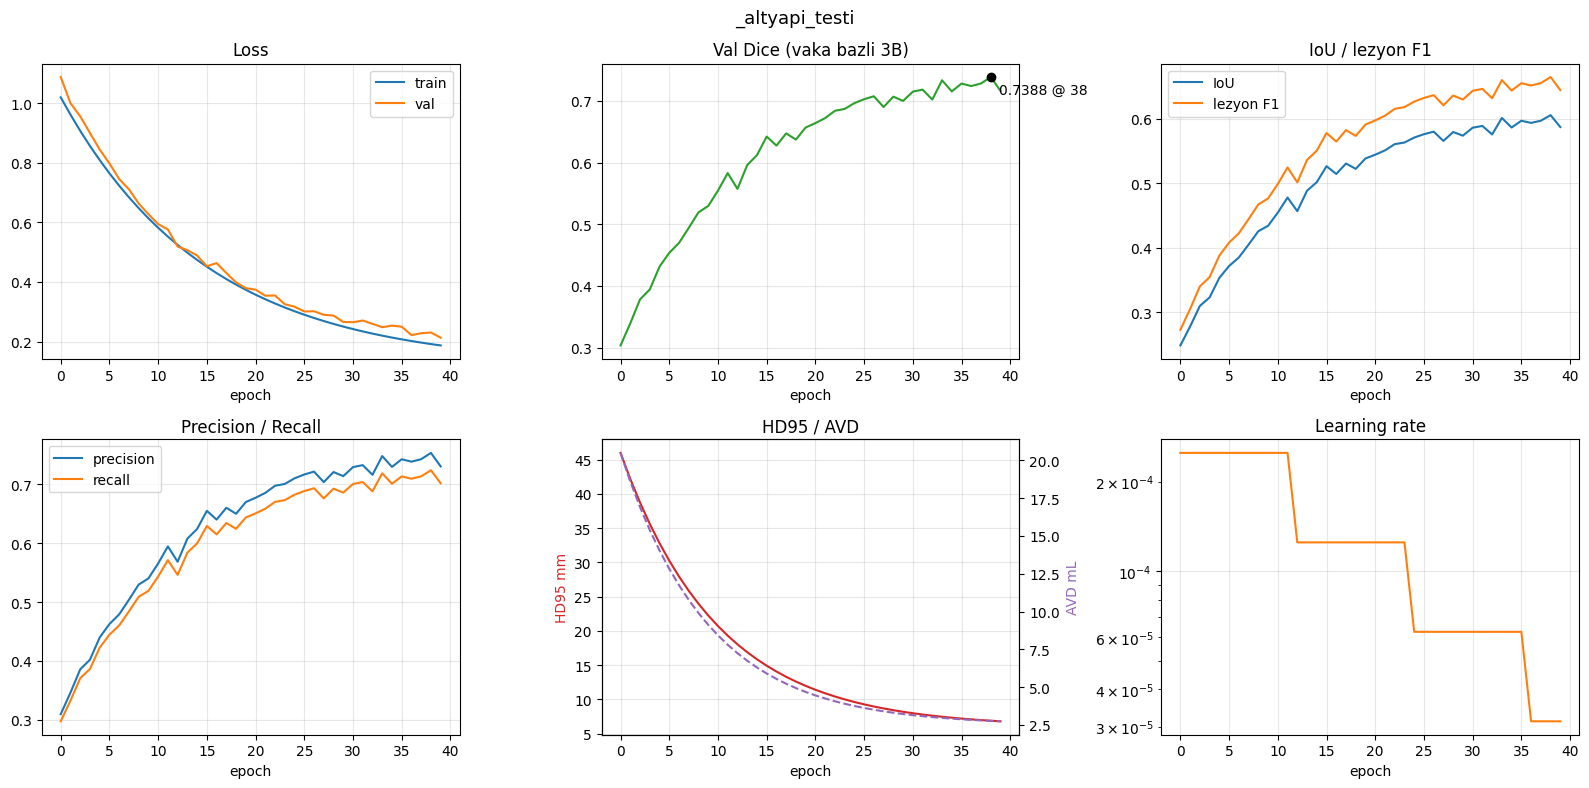

mirror: /content/outputs/_altyapi_testi -> ['_altyapi_testi_curves.png', '_altyapi_testi_log.xlsx', 'checkpoints']


In [10]:
fig = plot_training_curves(df, TEST_KEY, os.path.join(kok, f'{TEST_KEY}_curves.png'))
plt.show()
hedef = mirror_to_local(TEST_KEY)
print('mirror:', hedef, '->', sorted(os.listdir(hedef)))

In [11]:
# Test artefaktlarini temizle - gercek kosularla karismasin
shutil.rmtree(os.path.join(PROJE, TEST_KEY), ignore_errors=True)
shutil.rmtree(os.path.join(YEREL, TEST_KEY), ignore_errors=True)
print('temizlendi:', TEST_KEY)
print()
print('PARCA 3 TAMAM:')
print('  - SCHEMA + append_epoch_row (resume-safe, 40 epoch testi gecti)')
print('  - save/find_resumable/restore_checkpoint (stripped checkpoint yakalaniyor)')
print('  - mirror_to_local')
print('  - 3B metrikler: dice/iou/precision/recall/hd95/avd/lezyon_f1 (7 test gecti)')
print('  - plot_training_curves (2x3)')

temizlendi: _altyapi_testi

PARCA 3 TAMAM:
  - SCHEMA + append_epoch_row (resume-safe, 40 epoch testi gecti)
  - save/find_resumable/restore_checkpoint (stripped checkpoint yakalaniyor)
  - mirror_to_local
  - 3B metrikler: dice/iou/precision/recall/hd95/avd/lezyon_f1 (7 test gecti)
  - plot_training_curves (2x3)


---

# Parca 4 - Model fabrikasi, veri hatti, egitim dongusu

`PLAN.md` Bolum 4'teki 5 mimari + 3 ablasyon. `MODEL_KEY` hangi kosunun yapilacagini secer;
her sey `MODEL_CONFIGS` icinden okunur, hucrelerde sabit deger yok.

Bu bolumun sonunda **smoke test** var: kucuk bir alt kumede 2 epoch. Gecmeden Parca 5
baslatilmaz.

In [12]:
os.system('pip -q install segmentation-models-pytorch albumentations')
import segmentation_models_pytorch as smp
import albumentations as A
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader

CIHAZ = 'cuda' if torch.cuda.is_available() else 'cpu'
print('smp:', smp.__version__, '| albumentations:', A.__version__)
print('cihaz:', CIHAZ, torch.cuda.get_device_name(0) if CIHAZ == 'cuda' else '')

smp: 0.5.0 | albumentations: 2.0.8
cihaz: cuda Tesla T4


## 4.1 Model konfigurasyonlari

Hiperparametreler density projesindeki kalibre edilmis degerlerden turetildi (AdamW,
encoder/decoder ayri LR, ReduceLROnPlateau + 3 epoch warmup, gradient clipping, AMP).
`girdi_dilim` 2.5D baglam derinligini verir: `k` komsu -> `2k+1` dilim -> `(2k+1)*2` kanal.

In [13]:
MODEL_CONFIGS = {
    # --- 5 mimari ---
    'unet_r34_2d': dict(mimari='unet', encoder='resnet34', k=0, batch=32,
                        lr_enc=5e-5, lr_dec=2.5e-4, loss='dice_bce'),
    'unet_r34_25d': dict(mimari='unet', encoder='resnet34', k=2, batch=32,
                         lr_enc=5e-5, lr_dec=2.5e-4, loss='dice_bce'),
    'segformer_b0': dict(mimari='segformer', encoder='nvidia/mit-b0', k=2, batch=32,
                         lr_enc=1e-4, lr_dec=1e-4, loss='dice_bce'),
    'unet_mbv3': dict(mimari='unet', encoder='timm-mobilenetv3_large_100', k=2, batch=32,
                      lr_enc=1e-4, lr_dec=5e-4, loss='dice_bce'),
    # Tam hacim - patch degil. Kirpilmis hacimler 96x128x<=96'ya sigiyor (Parca 2 olcumu),
    # dolayisiyla patch'lemeye ve kaydirmali pencere cikarimina gerek yok. Vaka basina
    # tek ileri gecis, gercek zamanli hedefe de bu uyuyor.
    'unet3d': dict(mimari='unet3d', encoder=None, k=None, batch=2,
                   lr_enc=3e-4, lr_dec=3e-4, loss='dice_bce', tekrar=3),
    # --- ablasyonlar (Bolum 4) ---
    'A1_flair': dict(mimari='unet', encoder='resnet34', k=2, batch=32,
                     lr_enc=5e-5, lr_dec=2.5e-4, loss='dice_bce', flair=True),
    # Yalniz bolge kaybi degisiyor (Dice -> focal-Tversky); BCE terimi ve ornekleme orani
    # taban cizgisiyle ayni. Ilk tasarimda lezyon_orani da 0.7'ye cekiliyordu - iki degisken
    # birden degisince fark hangisinden geldigi ayrilamazdi.
    'A2_tversky': dict(mimari='unet', encoder='resnet34', k=2, batch=32,
                       lr_enc=5e-5, lr_dec=2.5e-4, loss='focal_tversky'),
    'A3_k1': dict(mimari='unet', encoder='resnet34', k=1, batch=32,
                  lr_enc=5e-5, lr_dec=2.5e-4, loss='dice_bce'),
    'A3_k3': dict(mimari='unet', encoder='resnet34', k=3, batch=32,
                  lr_enc=5e-5, lr_dec=2.5e-4, loss='dice_bce'),
}

ORTAK = dict(
    max_epochs=70, patience=15, warmup_epochs=3, weight_decay=1e-4,
    plateau_factor=0.5, plateau_patience=3, min_lr=1e-7,
    grad_clip=1.0, amp=True, seed=42, tekrar=1,
    lezyon_orani=0.5,     # egitimde lezyonlu dilim orani (kalan bos dilimden)
    esik=0.5,             # val'de sabit; nihai esik Parca 7'de taranacak
    flair=False,
)

def konfig(model_key):
    if model_key not in MODEL_CONFIGS:
        raise KeyError(f'{model_key!r} tanimli degil. Gecerli anahtarlar: '
                       + ', '.join(MODEL_CONFIGS))
    c = dict(ORTAK)
    c.update(MODEL_CONFIGS[model_key])
    c['model_key'] = model_key
    # FLAIR eklenince o da 2k+1 dilimlik baglamla geliyor: 3 modalite x (2k+1).
    # Ilk surumde '+1' yazilmisti (tek FLAIR dilimi) - 2.5D ablasyonuyla karsilastirilabilir
    # olmasi icin ucu de ayni baglami almali.
    modalite = 3 if c['flair'] else 2
    c['kanal'] = 2 if c['k'] is None else modalite * (2 * c['k'] + 1)
    return c

for k in MODEL_CONFIGS:
    c = konfig(k)
    print(f"{k:15s} {c['mimari']:9s} k={str(c['k']):4s} kanal={c['kanal']:3d} "
          f"batch={c['batch']:3d} loss={c['loss']}")

unet_r34_2d     unet      k=0    kanal=  2 batch= 32 loss=dice_bce
unet_r34_25d    unet      k=2    kanal= 10 batch= 32 loss=dice_bce
segformer_b0    segformer k=2    kanal= 10 batch= 32 loss=dice_bce
unet_mbv3       unet      k=2    kanal= 10 batch= 32 loss=dice_bce
unet3d          unet3d    k=None kanal=  2 batch=  2 loss=dice_bce
A1_flair        unet      k=2    kanal= 15 batch= 32 loss=dice_bce
A2_tversky      unet      k=2    kanal= 10 batch= 32 loss=focal_tversky
A3_k1           unet      k=1    kanal=  6 batch= 32 loss=dice_bce
A3_k3           unet      k=3    kanal= 14 batch= 32 loss=dice_bce


## 4.2 Veri hatti

Onbellek **bir kez RAM'e** aliniyor (0,80 GB) - Drive I/O epoch basina tekrar odenmesin diye.

Egitim ornegi = tek dilim (2D) veya `2k+1` komsu dilim (2.5D). Indeks lezyonlu ve bos
dilimler olarak ikiye ayrilip her epoch `lezyon_orani` ile karistiriliyor: **bos dilimler
atilmiyor** (Parca 1: beyin iceren dilimlerin %64,9'unda lezyon yok; atilirsa model bos
dilimde yanlis pozitif uretir ve hacim olcumu bozulur).

Val/test tarafinda augmentasyon yok, vaka butun olarak gecirilip 3B metrik hesaplaniyor.

In [14]:
H_HEDEF, W_HEDEF = CFG['girdi_H'], CFG['girdi_W']


def npy_yukle(vakalar, flair=False):
    d = {}
    for v in vakalar:
        kayit = dict(x=np.load(os.path.join(HAZIR, f'{v}_x.npy')),
                     y=np.load(os.path.join(HAZIR, f'{v}_y.npy')))
        if flair:
            fy = os.path.join(HAZIR, f'{v}_f.npy')
            if not os.path.exists(fy):
                raise FileNotFoundError(
                    f'{fy} yok. FLAIR onbellegi uretilmemis - once '
                    f'isles_veri_hazirlik.ipynb "Parca 2b - FLAIR hazirlama" bolumunu calistir.')
            kayit['x'] = np.concatenate([kayit['x'], np.load(fy)], axis=0)   # (3, h, w, d)
        d[v] = kayit
    return d


def dolgula(a, H=H_HEDEF, W=W_HEDEF):
    '''(.., h, w) -> (.., H, W) merkezden sifir dolgu. Tasarsa merkezden kirpar.

    Parca 2 olcumu: H max 87 <= 96, W max 101 <= 128, yani tasan vaka yok.
    Tasma olursa vaka_tahmin'deki dolgu-geri-alma matematigi bozulur - sessiz
    yanlis sonuc yerine burada gorunur olsun diye kirpma yolu uyari basiyor.'''
    h, w = a.shape[-2:]
    if h > H or w > W:
        print(f'UYARI: {h}x{w} hedefi ({H}x{W}) asiyor, merkezden kirpiliyor')
    ust, sol = (H - h) // 2, (W - w) // 2
    if h > H or w > W:
        y0, x0 = max((h - H) // 2, 0), max((w - W) // 2, 0)
        a = a[..., y0:y0 + min(h, H), x0:x0 + min(w, W)]
        h, w = a.shape[-2:]
        ust, sol = (H - h) // 2, (W - w) // 2
    pad = [(0, 0)] * (a.ndim - 2) + [(ust, H - h - ust), (sol, W - w - sol)]
    return np.pad(a, pad)


def augment_yap():
    return A.Compose([
        A.HorizontalFlip(p=0.5),
        A.Affine(scale=(0.9, 1.1), rotate=(-10, 10), translate_percent=(-0.05, 0.05), p=0.5),
        A.ElasticTransform(alpha=20, sigma=6, p=0.15),
    ])


def worker_init(worker_id):
    '''torch yalniz kendi RNG'sini worker basina tohumluyor; numpy ve random tohumsuz kalip
    her worker'da ayni augmentasyon akisini uretiyor. Elle tohumlaniyor.'''
    tohum = torch.initial_seed() % 2**31
    np.random.seed(tohum + worker_id)
    random.seed(tohum + worker_id)


class DilimVeri(Dataset):
    '''2D / 2.5D dilim veri seti. k=0 tek dilim, k>0 icin 2k+1 komsu dilim kanal olarak yiginlanir.'''

    def __init__(self, vakalar, veri, k, egitim, lezyon_orani=0.5, seed=42):
        self.veri, self.k, self.egitim = veri, (k or 0), egitim
        self.lezyon_orani = lezyon_orani
        self.aug = augment_yap() if egitim else None
        self.rng = np.random.default_rng(seed)
        self.lezyonlu, self.bos = [], []
        for v in vakalar:
            y = veri[v]['y']
            lez = y.sum(axis=(0, 1)) > 0
            for z in range(y.shape[2]):
                (self.lezyonlu if lez[z] else self.bos).append((v, z))
        self.karistir()

    def karistir(self):
        if not self.egitim:
            self.indeks = self.lezyonlu + self.bos
            return
        n_lez = len(self.lezyonlu)
        n_bos = int(n_lez * (1 - self.lezyon_orani) / max(self.lezyon_orani, 1e-6))
        secilen = [self.bos[i] for i in self.rng.choice(len(self.bos), min(n_bos, len(self.bos)),
                                                        replace=False)] if self.bos else []
        self.indeks = self.lezyonlu + secilen
        self.rng.shuffle(self.indeks)

    def __len__(self):
        return len(self.indeks)

    def __getitem__(self, i):
        v, z = self.indeks[i]
        x, y = self.veri[v]['x'], self.veri[v]['y']
        D = x.shape[3]
        zs = np.clip(np.arange(z - self.k, z + self.k + 1), 0, D - 1)   # kenarda tekrarla
        img = x[:, :, :, zs].astype(np.float32)          # (M, h, w, 2k+1), M = modalite
        img = img.transpose(1, 2, 0, 3).reshape(img.shape[1], img.shape[2], -1)   # (h, w, C)
        msk = y[:, :, z].astype(np.float32)

        if self.aug is not None:
            o = self.aug(image=img, mask=msk)
            img, msk = o['image'], o['mask']
            msk = (msk > 0.5).astype(np.float32)      # augmentasyon maskeyi araya sokmasin
            if self.rng.random() < 0.3:
                # Kanal duzeni modalite-onculu: [DWI x (2k+1)] + [ADC x (2k+1)].
                # Jitter yalniz DWI'ya; ADC fizik birimli, olcegi bozulmamali.
                n_dwi = 2 * self.k + 1
                img[..., :n_dwi] = (img[..., :n_dwi] * self.rng.uniform(0.9, 1.1)
                                    + self.rng.uniform(-0.1, 0.1))

        img = dolgula(img.transpose(2, 0, 1))             # (C, H, W)
        msk = dolgula(msk[None])[0]                       # (H, W)
        return torch.from_numpy(np.ascontiguousarray(img)), torch.from_numpy(msk[None])


# --- 3B hacim veri hatti ---
# Dolgu hedefi: her eksen 8'in kati olmali (UNet3D uc kez 2 kat asagi ornekliyor).
D_HEDEF = int(np.ceil(MAN.D.max() / 8) * 8)
assert H_HEDEF % 8 == 0 and W_HEDEF % 8 == 0 and D_HEDEF % 8 == 0, (H_HEDEF, W_HEDEF, D_HEDEF)


def hacim_ofset(sekil):
    """(h, w, d) -> merkezden dolgu ofsetleri."""
    return tuple((H - v) // 2 for v, H in zip(sekil, (H_HEDEF, W_HEDEF, D_HEDEF)))


def hacim_dolgula(a):
    """(.., h, w, d) -> (.., H_HEDEF, W_HEDEF, D_HEDEF) merkezden sifir dolgu."""
    h, w, d = a.shape[-3:]
    o = hacim_ofset((h, w, d))
    pad = [(0, 0)] * (a.ndim - 3) + [(o[0], H_HEDEF - h - o[0]),
                                     (o[1], W_HEDEF - w - o[1]),
                                     (o[2], D_HEDEF - d - o[2])]
    return np.pad(a, pad)


class HacimVeri(Dataset):
    """Tam hacim veri seti (3B U-Net). Bir ornek = bir vakanin tamami.

    `tekrar`: 2B kosularda epoch basina ~237 optimizer adimi var (7602 dilim / batch 32).
    3B'de 161 vaka / batch 2 = 81 adim kalirdi; tekrar=3 ile 241 adima cikip epoch tanimi
    kabaca esitleniyor. Aksi halde "3B daha kotu" sonucu mimariden mi az adimdan mi geldigi
    ayrilamazdi."""

    def __init__(self, vakalar, veri, egitim, tekrar=1, seed=42):
        self.vakalar, self.veri, self.egitim = list(vakalar), veri, egitim
        self.tekrar = tekrar if egitim else 1
        self.rng = np.random.default_rng(seed)

    def __len__(self):
        return len(self.vakalar) * self.tekrar

    def __getitem__(self, i):
        v = self.vakalar[i % len(self.vakalar)]
        x = self.veri[v]['x'].astype(np.float32)      # (2, h, w, d)
        y = self.veri[v]['y'].astype(np.float32)      # (h, w, d)
        if self.egitim:
            if self.rng.random() < 0.5:               # sol-sag flip
                x, y = x[:, ::-1], y[::-1]
            if self.rng.random() < 0.3:               # on-arka flip
                x, y = x[:, :, ::-1], y[:, ::-1]
            if self.rng.random() < 0.3:               # yogunluk jitter yalniz DWI kanalina
                x = x.copy()
                x[0] = x[0] * self.rng.uniform(0.9, 1.1) + self.rng.uniform(-0.1, 0.1)
        x = hacim_dolgula(np.ascontiguousarray(x))
        y = hacim_dolgula(np.ascontiguousarray(y)[None])[0]
        return torch.from_numpy(x), torch.from_numpy(y[None])


def veri_seti_yap(vakalar, veri, c, egitim):
    """Mimarisine gore dogru veri setini secer."""
    if c['mimari'] == 'unet3d':
        return HacimVeri(vakalar, veri, egitim, tekrar=c['tekrar'], seed=c['seed'])
    return DilimVeri(vakalar, veri, c['k'], egitim=egitim,
                     lezyon_orani=c['lezyon_orani'], seed=c['seed'])


## 4.3 Model fabrikasi

`smp` `in_channels != 3` icin ImageNet ilk katmanini kendisi uyarliyor. SegFormer'da bu
otomatik degil - ilk patch embedding elle genisletiliyor (kanal ortalamasi kopyalanir).

In [15]:
class UNet3D(nn.Module):
    '''Kompakt 3B U-Net - dogruluk tavani referansi. 6 GB VRAM kisiti nedeniyle dar tutuldu.'''

    def __init__(self, kanal=2, taban=16):
        super().__init__()
        blok = lambda gi, go: nn.Sequential(
            nn.Conv3d(gi, go, 3, padding=1), nn.InstanceNorm3d(go), nn.LeakyReLU(inplace=True),
            nn.Conv3d(go, go, 3, padding=1), nn.InstanceNorm3d(go), nn.LeakyReLU(inplace=True))
        f = [taban, taban * 2, taban * 4, taban * 8]
        self.e1, self.e2, self.e3 = blok(kanal, f[0]), blok(f[0], f[1]), blok(f[1], f[2])
        self.alt = blok(f[2], f[3])
        self.u3 = nn.ConvTranspose3d(f[3], f[2], 2, 2); self.d3 = blok(f[3], f[2])
        self.u2 = nn.ConvTranspose3d(f[2], f[1], 2, 2); self.d2 = blok(f[2], f[1])
        self.u1 = nn.ConvTranspose3d(f[1], f[0], 2, 2); self.d1 = blok(f[1], f[0])
        self.cikis = nn.Conv3d(f[0], 1, 1)
        self.havuz = nn.MaxPool3d(2)

    def forward(self, x):
        e1 = self.e1(x); e2 = self.e2(self.havuz(e1)); e3 = self.e3(self.havuz(e2))
        a = self.alt(self.havuz(e3))
        d = self.d3(torch.cat([self.u3(a), e3], 1))
        d = self.d2(torch.cat([self.u2(d), e2], 1))
        d = self.d1(torch.cat([self.u1(d), e1], 1))
        return self.cikis(d)


def _ilk_conv_bul(net):
    """Patch embedding conv'unu YOLA GORE degil, ARAYARAK bulur.

    transformers surumleri arasinda modul yolu degisiyor (5.x'te
    net.segformer.encoder.patch_embeddings[0].proj artik yok). Girdisi 3 kanalli ilk
    Conv2d patch embedding'dir; yoksa ilk Conv2d'ye dusulur."""
    ilk = None
    for ad, m in net.named_modules():
        if isinstance(m, nn.Conv2d):
            if m.in_channels == 3:
                return ad, m
            if ilk is None:
                ilk = (ad, m)
    return ilk if ilk else (None, None)


def _modul_ata(net, ad, yeni_modul):
    parcalar = ad.split('.')
    ust = net
    for p in parcalar[:-1]:
        ust = ust[int(p)] if p.isdigit() else getattr(ust, p)
    son = parcalar[-1]
    if son.isdigit():
        ust[int(son)] = yeni_modul
    else:
        setattr(ust, son, yeni_modul)


class SegFormerSarmal(nn.Module):
    """transformers SegFormer + kanal uyarlamasi + tam cozunurluge upsample."""

    def __init__(self, ad, kanal):
        super().__init__()
        from transformers import SegformerForSemanticSegmentation
        self.net = SegformerForSemanticSegmentation.from_pretrained(
            ad, num_labels=1, ignore_mismatched_sizes=True)
        yol, eski = _ilk_conv_bul(self.net)
        if eski is None:
            raise RuntimeError('SegFormer icinde Conv2d bulunamadi')
        print(f'  patch embedding: {yol}  in_channels={eski.in_channels} -> {kanal}')
        if kanal != eski.in_channels:
            yeni = nn.Conv2d(kanal, eski.out_channels, eski.kernel_size,
                             eski.stride, eski.padding, bias=eski.bias is not None)
            with torch.no_grad():
                ort = eski.weight.mean(dim=1, keepdim=True)
                yeni.weight.copy_(ort.repeat(1, kanal, 1, 1) * (eski.in_channels / kanal))
                if eski.bias is not None:
                    yeni.bias.copy_(eski.bias)
            _modul_ata(self.net, yol, yeni)

    def forward(self, x):
        y = self.net(pixel_values=x).logits            # 1/4 cozunurluk
        return F.interpolate(y, size=x.shape[-2:], mode='bilinear', align_corners=False)


def model_yap(c):
    if c['mimari'] == 'unet':
        return smp.Unet(encoder_name=c['encoder'], encoder_weights='imagenet',
                        in_channels=c['kanal'], classes=1)
    if c['mimari'] == 'segformer':
        return SegFormerSarmal(c['encoder'], c['kanal'])
    if c['mimari'] == 'unet3d':
        return UNet3D(kanal=2)
    raise ValueError(c['mimari'])


def parametre_sayisi(m):
    return sum(p.numel() for p in m.parameters())


def parametre_gruplari(model, c):
    '''Encoder ve decoder farkli LR alir (smp'de encoder ayri modul).'''
    if hasattr(model, 'encoder'):
        enc = list(model.encoder.parameters())
        enc_id = {id(p) for p in enc}
        dec = [p for p in model.parameters() if id(p) not in enc_id]
        return [{'params': enc, 'lr': c['lr_enc']}, {'params': dec, 'lr': c['lr_dec']}]
    return [{'params': list(model.parameters()), 'lr': c['lr_dec']}]

## 4.4 Loss

`dice_bce` taban cizgisi. `focal_tversky` A2 ablasyonu icin: `beta > alpha` yanlis negatifi
daha agir cezalandirir, kucuk lezyonlarda recall'u yukseltmesi bekleniyor (Parca 1: lezyon
voxel orani medyan %0,53).

In [16]:
class DiceBCE(nn.Module):
    def __init__(self, agirlik_bce=0.5, duz=1.0):
        super().__init__()
        self.w, self.duz = agirlik_bce, duz
        self.bce = nn.BCEWithLogitsLoss()

    def forward(self, logit, hedef):
        p = torch.sigmoid(logit)
        kesisim = (p * hedef).sum(dim=(1, 2, 3))
        dice = 1 - (2 * kesisim + self.duz) / (p.sum(dim=(1, 2, 3)) + hedef.sum(dim=(1, 2, 3)) + self.duz)
        return self.w * self.bce(logit, hedef) + (1 - self.w) * dice.mean()


class FocalTversky(nn.Module):
    '''BCE + focal-Tversky. Iki duzeltme (ilk A2 kosusu bu ikisi yuzunden coktu):

    1. gamma = 4/3 (Abraham & Khan 2019). Ilk surumde 0.75 yazilmisti - tersi. gamma<1
       kolay orneklerde gradyani buyutuyor, focal'in amacinin tam tersi.
    2. BCE terimi eklendi. SAF bolge kaybi doygunluk tuzagi yaratiyor: model her seyi
       lezyon dediginde loss 0.98 ama gradyan 1.6e-6 (sigmoid doymus, fn=0) - cikis yok.
       BCE'nin gradyani (p-y), doymuyor; ayni durumda gradyan 0.50. Olculdu.

    alpha FP'yi, beta FN'i agirliklandirir; beta>alpha yanlis negatifi daha agir cezalandirir
    (kucuk lezyonlarda recall hedefi).'''

    def __init__(self, alpha=0.3, beta=0.7, gamma=4/3, duz=1.0, agirlik_bce=0.5):
        super().__init__()
        self.a, self.b, self.g, self.duz, self.w = alpha, beta, gamma, duz, agirlik_bce
        self.bce = nn.BCEWithLogitsLoss()

    def forward(self, logit, hedef):
        p = torch.sigmoid(logit)
        tp = (p * hedef).sum(dim=(1, 2, 3))
        fp = (p * (1 - hedef)).sum(dim=(1, 2, 3))
        fn = ((1 - p) * hedef).sum(dim=(1, 2, 3))
        tv = (tp + self.duz) / (tp + self.a * fp + self.b * fn + self.duz)
        ft = ((1 - tv) ** self.g).mean()
        return self.w * self.bce(logit, hedef) + (1 - self.w) * ft


def loss_yap(c):
    return DiceBCE() if c['loss'] == 'dice_bce' else FocalTversky()

### Loss testleri

Metrikler yedi senaryoyla test edilmisti ama **loss'lar hic test edilmemisti** ve ilk `A2_tversky`
kosusu bu yuzden 28 dakika bosa gitti. Asagidaki kontrol, bir loss'un **cokus durumundan
(her seyi lezyon demek) cikis gradyani uretip uretmedigini** olcuyor - saf bolge kayiplarinin
klasik doygunluk tuzagi.

In [17]:
# Loss testleri - bir kosuyu 28 dakika bosa harcamadan once.
# Ilk A2 kosusu saf focal-Tversky ile coktu (test Dice 0.044); sebep asagidaki
# "cokus" senaryosunda gradyanin yok olmasiydi. Bu hucre onu yakalar.
_H = _W = 96
_gt = torch.zeros(1, 1, _H, _W, device='cpu')
_gt[0, 0, 40:46, 40:46] = 1                      # %0.39 lezyon - gercege yakin oran

_senaryo = {
    'mukemmel':      _gt * 20 - 10,
    'cokus (hepsi lezyon)': torch.full((1, 1, _H, _W), 10.0),
    'hepsi arkaplan': torch.full((1, 1, _H, _W), -10.0),
    'yarim dogru':   torch.where(_gt.bool(), 2.0, -4.0),
}

print(f'{"loss":16s} {"senaryo":22s} {"deger":>8s} {"|grad| toplam":>14s}')
_sonuc = {}
for _ad, _fn in [('dice_bce', DiceBCE()), ('focal_tversky', FocalTversky())]:
    for _k, _lg in _senaryo.items():
        _l = _lg.clone().requires_grad_(True)
        _v = _fn(_l, _gt)
        _v.backward()
        _g = _l.grad.abs().sum().item()
        _sonuc[(_ad, _k)] = (_v.item(), _g)
        print(f'{_ad:16s} {_k:22s} {_v.item():8.4f} {_g:14.3e}')
    print()

for _ad in ('dice_bce', 'focal_tversky'):
    _v_iyi, _g_iyi = _sonuc[(_ad, 'mukemmel')]
    _v_kotu, _g_kotu = _sonuc[(_ad, 'cokus (hepsi lezyon)')]
    _, _g_yarim = _sonuc[(_ad, 'yarim dogru')]
    assert _v_kotu > _v_iyi, f'{_ad}: cokus durumu mukemmelden dusuk loss veriyor'
    # Kritik kontrol: cokus durumundan cikis gradyani olmali. Saf focal-Tversky'de
    # bu oran 5e-6 idi (doygunluk tuzagi) - model bir kez cokunce kurtulamiyordu.
    _oran = _g_kotu / max(_g_yarim, 1e-12)
    assert _oran > 0.01, (f'{_ad}: cokus gradyani "yarim dogru"nun {_oran:.1e} kati - '
                          f'doygunluk tuzagi, model cokusten cikamaz')
    print(f'{_ad:16s} cokus/yarim gradyan orani {_oran:6.3f}  OK')

print('\nLOSS TESTLERI GECTI')


loss             senaryo                   deger  |grad| toplam
dice_bce         mukemmel                 0.0029      2.856e-03
dice_bce         cokus (hepsi lezyon)     5.4765      4.980e-01
dice_bce         hepsi arkaplan           0.5061      2.168e-03
dice_bce         yarim dogru              0.3715      1.187e-01

focal_tversky    mukemmel                 0.0003      3.622e-04
focal_tversky    cokus (hepsi lezyon)     5.4717      4.980e-01
focal_tversky    hepsi arkaplan           0.4944      2.135e-03
focal_tversky    yarim dogru              0.2715      1.557e-01

dice_bce         cokus/yarim gradyan orani  4.197  OK
focal_tversky    cokus/yarim gradyan orani  3.199  OK

LOSS TESTLERI GECTI


## 4.5 Val: vakayi butun olarak gecir, 3B metrik hesapla

Dilim basina metrik yaniltici oldugu icin (Bolum 5) val'de her vakanin butun dilimleri
gecirilip hacim yeniden kuruluyor, metrikler o hacim uzerinde hesaplaniyor.

In [18]:
@torch.no_grad()
def vaka_tahmin(model, veri, vaka, c, cihaz=CIHAZ, kayip_fn=None):
    """Tek vakanin tam hacim tahminini dondurur (orijinal kirpilmis sekilde, bool).

    kayip_fn verilirse ayni ileri gecisten GERCEK val loss'u da hesaplar - train_loss ile
    ayni tanim, ayni olcek. Onceki surumde val_loss = 1 - Dice idi; o sayi train_loss ile
    karsilastirilamaz oldugu icin egri panelindeki train/val makasi anlamsizdi."""
    model.eval()
    x, y = veri[vaka]['x'], veri[vaka]['y']
    h, w, D = x.shape[1], x.shape[2], x.shape[3]

    if c['mimari'] == 'unet3d':
        # Tam hacim tek ileri gecis; kaydirmali pencere yok.
        xt = torch.from_numpy(hacim_dolgula(x.astype(np.float32)))[None].to(cihaz)
        ht = torch.from_numpy(hacim_dolgula(y.astype(np.float32)[None]))[None].to(cihaz)             if kayip_fn is not None else None
        with torch.amp.autocast('cuda', enabled=(c['amp'] and cihaz == 'cuda')):
            logit = model(xt)
        logit = logit.float()
        kayip = kayip_fn(logit, ht).item() if kayip_fn is not None else float('nan')
        p = torch.sigmoid(logit)[0, 0].cpu().numpy()
        o = hacim_ofset((h, w, D))
        p = p[o[0]:o[0] + h, o[1]:o[1] + w, o[2]:o[2] + D]
        return p >= c['esik'], y.astype(bool), kayip

    k = c['k'] or 0
    yigin = []
    for z in range(D):
        zs = np.clip(np.arange(z - k, z + k + 1), 0, D - 1)
        img = x[:, :, :, zs].astype(np.float32).transpose(1, 2, 0, 3).reshape(h, w, -1)
        yigin.append(dolgula(img.transpose(2, 0, 1)))
    t = torch.from_numpy(np.stack(yigin)).to(cihaz)

    hedef = None
    if kayip_fn is not None:
        hedef = torch.from_numpy(
            np.stack([dolgula(y[:, :, z][None].astype(np.float32))[0] for z in range(D)])
        )[:, None].to(cihaz)

    cikti, kayip_toplam = [], 0.0
    for i in range(0, len(t), c['batch']):
        with torch.amp.autocast('cuda', enabled=(c['amp'] and cihaz == 'cuda')):
            logit = model(t[i:i + c['batch']])
        logit = logit.float()
        if kayip_fn is not None:
            kayip_toplam += kayip_fn(logit, hedef[i:i + c['batch']]).item() * logit.size(0)
        cikti.append(torch.sigmoid(logit).cpu())
    p = torch.cat(cikti)[:, 0].numpy()                 # (D, H, W)
    ust, sol = (H_HEDEF - h) // 2, (W_HEDEF - w) // 2  # dolguyu geri al
    p = p[:, ust:ust + h, sol:sol + w].transpose(1, 2, 0)
    kayip = kayip_toplam / len(t) if kayip_fn is not None else float('nan')
    return p >= c['esik'], y.astype(bool), kayip


def val_degerlendir(model, veri, vakalar, c, kayip_fn=None):
    sonuc = [vaka_tahmin(model, veri, v, c, kayip_fn=kayip_fn) for v in vakalar]
    m = [vaka_metrikleri(t, g) for t, g, _ in sonuc]
    val_loss = float(np.mean([kl for _, _, kl in sonuc]))
    return topla(m), m, val_loss


## 4.6 Egitim dongusu

Density projesindeki desen: 3 epoch lineer warmup -> `ReduceLROnPlateau` (val loss), AMP +
gradient clipping, val Dice'a gore early stopping, her epoch `last.pt` + Excel satiri,
iyilesince `best.pt`.

In [19]:
def egit(model_key, resume=False, max_epochs=None, train_vakalar=None, val_vakalar=None,
         log_ekle=True):
    c = konfig(model_key)
    if max_epochs:
        c['max_epochs'] = max_epochs
    torch.manual_seed(c['seed']); np.random.seed(c['seed']); random.seed(c['seed'])
    torch.backends.cudnn.deterministic = True

    tr = train_vakalar or SPLIT['train']
    va = val_vakalar or SPLIT['val']
    veri = npy_yukle(sorted(set(tr) | set(va)), flair=c['flair'])
    ds_tr = veri_seti_yap(tr, veri, c, egitim=True)

    # Kanal sayisi uyusmazligi ilk conv'da degil BURADA patlasin: hata mesaji anlasilir olsun.
    ornek_x, ornek_y = ds_tr[0]
    if ornek_x.shape[0] != c['kanal']:
        raise RuntimeError(f"{model_key}: veri {ornek_x.shape[0]} kanal uretiyor, konfig "
                           f"{c['kanal']} bekliyor. flair={c['flair']}, k={c['k']}")
    dl_tr = DataLoader(ds_tr, batch_size=c['batch'], shuffle=True, num_workers=2,
                       pin_memory=True, drop_last=True, worker_init_fn=worker_init)

    model = model_yap(c).to(CIHAZ)
    opt = torch.optim.AdamW(parametre_gruplari(model, c), weight_decay=c['weight_decay'])
    sch = torch.optim.lr_scheduler.ReduceLROnPlateau(
        opt, factor=c['plateau_factor'], patience=c['plateau_patience'], min_lr=c['min_lr'])
    scaler = torch.amp.GradScaler('cuda', enabled=(c['amp'] and CIHAZ == 'cuda'))
    kayip_fn = loss_yap(c)
    hedef_lr = [g['lr'] for g in opt.param_groups]

    kok, log_yol = log_baslat(model_key, resume=resume)
    bas_epoch, best_dice, ewi = 0, 0.0, 0
    if resume:
        yol, durum = find_resumable_checkpoint(kok)
        if durum:
            ep, best_dice, ewi = restore_checkpoint(durum, model, opt, sch, scaler)
            bas_epoch = ep + 1
            print(f'resume: epoch {bas_epoch} den devam, best_dice={best_dice:.4f}')

    birim = 'hacim' if c['mimari'] == 'unet3d' else 'dilim'
    ek = f" ({len(ds_tr.lezyonlu)} lezyonlu)" if hasattr(ds_tr, 'lezyonlu') else ''
    print(f"{model_key} | {parametre_sayisi(model)/1e6:.2f} M parametre | "
          f"{len(ds_tr)} egitim {birim}{ek} | {len(ds_tr)//c['batch']} adim/epoch"
          f" | {len(va)} val vakasi")

    for ep in range(bas_epoch, c['max_epochs']):
        t0 = time.time()
        if ep < c['warmup_epochs']:                        # lineer warmup
            for g, hl in zip(opt.param_groups, hedef_lr):
                g['lr'] = hl * (ep + 1) / c['warmup_epochs']
        if hasattr(ds_tr, 'karistir'):
            ds_tr.karistir()

        model.train()
        toplam = 0.0
        for xb, yb in dl_tr:
            xb, yb = xb.to(CIHAZ, non_blocking=True), yb.to(CIHAZ, non_blocking=True)
            opt.zero_grad(set_to_none=True)
            with torch.amp.autocast('cuda', enabled=(c['amp'] and CIHAZ == 'cuda')):
                kayip = kayip_fn(model(xb), yb)
            scaler.scale(kayip).backward()
            scaler.unscale_(opt)
            nn.utils.clip_grad_norm_(model.parameters(), c['grad_clip'])
            scaler.step(opt); scaler.update()
            toplam += kayip.item() * xb.size(0)
        train_loss = toplam / max(len(ds_tr), 1)

        ozet, _, val_loss = val_degerlendir(model, veri, va, c, kayip_fn=kayip_fn)
        if ep >= c['warmup_epochs']:
            sch.step(val_loss)

        # Once checkpoint, sonra log: epoch_sure_sn Drive'a yazma maliyetini de kapsasin.
        # (Smoke testte train+val 3 sn, checkpoint yazimi ~6 sn ciktı - disarida birakmak
        # epoch maliyetini yariya yakin eksik gosteriyordu.)
        iyi = ozet['dice'] > best_dice
        if iyi:
            best_dice, ewi = ozet['dice'], 0
        else:
            ewi += 1
        save_checkpoint(os.path.join(kok, 'checkpoints', 'last.pt'), model, opt, sch, scaler,
                        ep, best_dice, ewi)
        if iyi:
            save_checkpoint(os.path.join(kok, 'checkpoints', 'best.pt'), model, opt, sch, scaler,
                            ep, best_dice, ewi)

        satir = dict(epoch=ep, train_loss=train_loss, val_loss=val_loss,
                     dice=ozet['dice'], iou=ozet['iou'], precision=ozet['precision'],
                     recall=ozet['recall'], f1=ozet['dice'], hd95=ozet['hd95'],
                     avd_ml=ozet['avd_ml'], lezyon_f1=ozet['lezyon_f1'],
                     lr=opt.param_groups[-1]['lr'], epoch_sure_sn=time.time() - t0)
        if log_ekle:
            df = append_epoch_row(log_yol, satir, resume_epoch=(bas_epoch if ep == bas_epoch and resume else None))

        print(f"ep {ep:3d} | train {train_loss:.4f} | val {val_loss:.4f} | dice {ozet['dice']:.4f}"
              f"{' *' if iyi else '  '} | iou {ozet['iou']:.4f} | hd95 {ozet['hd95']:6.2f}"
              f" | avd {ozet['avd_ml']:6.2f} | lezF1 {ozet['lezyon_f1']:.3f}"
              f" | lr {opt.param_groups[-1]['lr']:.2e} | {time.time()-t0:.0f} sn")

        if ewi >= c['patience']:
            print(f'early stopping: {c["patience"]} epoch iyilesme yok')
            break

    if log_ekle:
        plot_training_curves(pd.read_excel(log_yol), model_key,
                             os.path.join(kok, f'{model_key}_curves.png'))
        mirror_to_local(model_key)
    return model, best_dice

## 4.7 Smoke test

Kucuk alt kume, 2 epoch, iki mimari (en hafif ve en agir 2B). Kontrol edilenler: sekiller,
kayip sonlu ve azaliyor, 13 log kolonunun hepsi dolu, checkpoint + resume calisiyor.

In [20]:
# Once tek batch ile butun mimarilerin sekil/parametre kontrolu (egitim yok)
kucuk_tr = SPLIT['train'][:6]
kucuk_va = SPLIT['val'][:3]
veri_kucuk = npy_yukle(sorted(set(kucuk_tr) | set(kucuk_va)))

# TUM mimariler - 3B dahil. Ilk surumde 3B disarida birakilmisti ve veri hattinin
# 2B dilim uretmesi ancak tam egitim baslayinca ortaya cikti; kontrol artik eksiksiz.
for mk in ['unet_r34_2d', 'unet_r34_25d', 'segformer_b0', 'unet_mbv3', 'unet3d']:
    c = konfig(mk)
    ds = veri_seti_yap(kucuk_tr, veri_kucuk, c, egitim=True)
    xb, yb = next(iter(DataLoader(ds, batch_size=min(4, c['batch']))))
    m = model_yap(c).to(CIHAZ)
    with torch.no_grad():
        out = m(xb.to(CIHAZ))
    assert out.shape == yb.shape, f'{mk}: cikti {out.shape} != hedef {yb.shape}'
    assert xb.shape[1] == c['kanal'], f'{mk}: kanal {xb.shape[1]} != {c["kanal"]}'
    beklenen_boyut = 5 if c['mimari'] == 'unet3d' else 4
    assert xb.ndim == beklenen_boyut, f'{mk}: {xb.ndim}B tensor, {beklenen_boyut}B bekleniyordu'
    vram = torch.cuda.max_memory_allocated() / 1e9 if CIHAZ == 'cuda' else 0
    print(f'{mk:15s} girdi {tuple(xb.shape)} -> cikti {tuple(out.shape)} | '
          f'{parametre_sayisi(m)/1e6:6.2f} M | pik VRAM {vram:.2f} GB')
    if CIHAZ == 'cuda':
        torch.cuda.reset_peak_memory_stats()
    del m
    torch.cuda.empty_cache() if CIHAZ == 'cuda' else None
print('\nSEKIL KONTROLU GECTI')

/usr/local/lib/python3.13/dist-packages/huggingface_hub/utils/_auth.py:138: UserWarning: 
Error while fetching `HF_TOKEN` secret value from your vault: 'Requesting secret HF_TOKEN timed out. Secrets can only be fetched when running from the Colab UI.'.
  warnings.warn(f"\nError while fetching `HF_TOKEN` secret value from your vault: '{str(e)}'.")


unet_r34_2d     girdi (4, 2, 96, 128) -> cikti (4, 1, 96, 128) |  24.43 M | pik VRAM 0.13 GB
unet_r34_25d    girdi (4, 10, 96, 128) -> cikti (4, 1, 96, 128) |  24.46 M | pik VRAM 0.13 GB


[transformers] You passed `num_labels=1` which is incompatible to the `id2label` map of length `1000`.


Loading weights:   0%|          | 0/192 [00:00<?, ?it/s]

[transformers] SegformerForSemanticSegmentation LOAD REPORT from: nvidia/mit-b0
Key                                                     | Status     | 
--------------------------------------------------------+------------+-
classifier.weight                                       | UNEXPECTED | 
classifier.bias                                         | UNEXPECTED | 
decode_head.batch_norm.num_batches_tracked              | MISSING    | 
decode_head.linear_projections.{0, 1, 2, 3}.proj.bias   | MISSING    | 
decode_head.batch_norm.running_mean                     | MISSING    | 
decode_head.classifier.weight                           | MISSING    | 
decode_head.linear_fuse.weight                          | MISSING    | 
decode_head.batch_norm.bias                             | MISSING    | 
decode_head.batch_norm.weight                           | MISSING    | 
decode_head.linear_projections.{0, 1, 2, 3}.proj.weight | MISSING    | 
decode_head.classifier.bias                             

  patch embedding: segformer.stages.0.patch_embeddings.proj  in_channels=3 -> 10
segformer_b0    girdi (4, 10, 96, 128) -> cikti (4, 1, 96, 128) |   3.73 M | pik VRAM 0.10 GB


unet_mbv3       girdi (4, 10, 96, 128) -> cikti (4, 1, 96, 128) |   6.69 M | pik VRAM 0.07 GB
unet3d          girdi (2, 2, 96, 128, 96) -> cikti (2, 1, 96, 128, 96) |   1.40 M | pik VRAM 0.90 GB

SEKIL KONTROLU GECTI


_smoke | 24.43 M parametre | 338 egitim dilim (169 lezyonlu) | 10 adim/epoch | 3 val vakasi
ep   0 | train 0.9150 | val 0.9671 | dice 0.0023 * | iou 0.0012 | hd95 109.14 | avd 3047.60 | lezF1 0.000 | lr 8.33e-05 | 61 sn


/tmp/ipykernel_76019/4229486145.py:15: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  df = pd.concat([df, pd.DataFrame([{k: satir.get(k, np.nan) for k in SCHEMA}])], ignore_index=True)


ep   1 | train 0.8281 | val 0.8504 | dice 0.0028 * | iou 0.0014 | hd95 110.92 | avd 2157.48 | lezF1 0.000 | lr 1.67e-04 | 149 sn

log kolonlari: ['epoch', 'train_loss', 'val_loss', 'dice', 'iou', 'precision', 'recall', 'f1', 'hd95', 'avd_ml', 'lezyon_f1', 'lr', 'epoch_sure_sn']
13/13 kolon dolu, kayiplar sonlu
 epoch  train_loss  val_loss     dice      iou  precision   recall       f1       hd95  avd_ml  lezyon_f1       lr  epoch_sure_sn
     0    0.915020  0.967053 0.002311 0.001158   0.001159 0.895740 0.002311 109.136012 3047.60          0 0.000083      60.678421
     1    0.828086  0.850402 0.002791 0.001401   0.001402 0.484746 0.002791 110.918132 2157.48          0 0.000167     149.238427


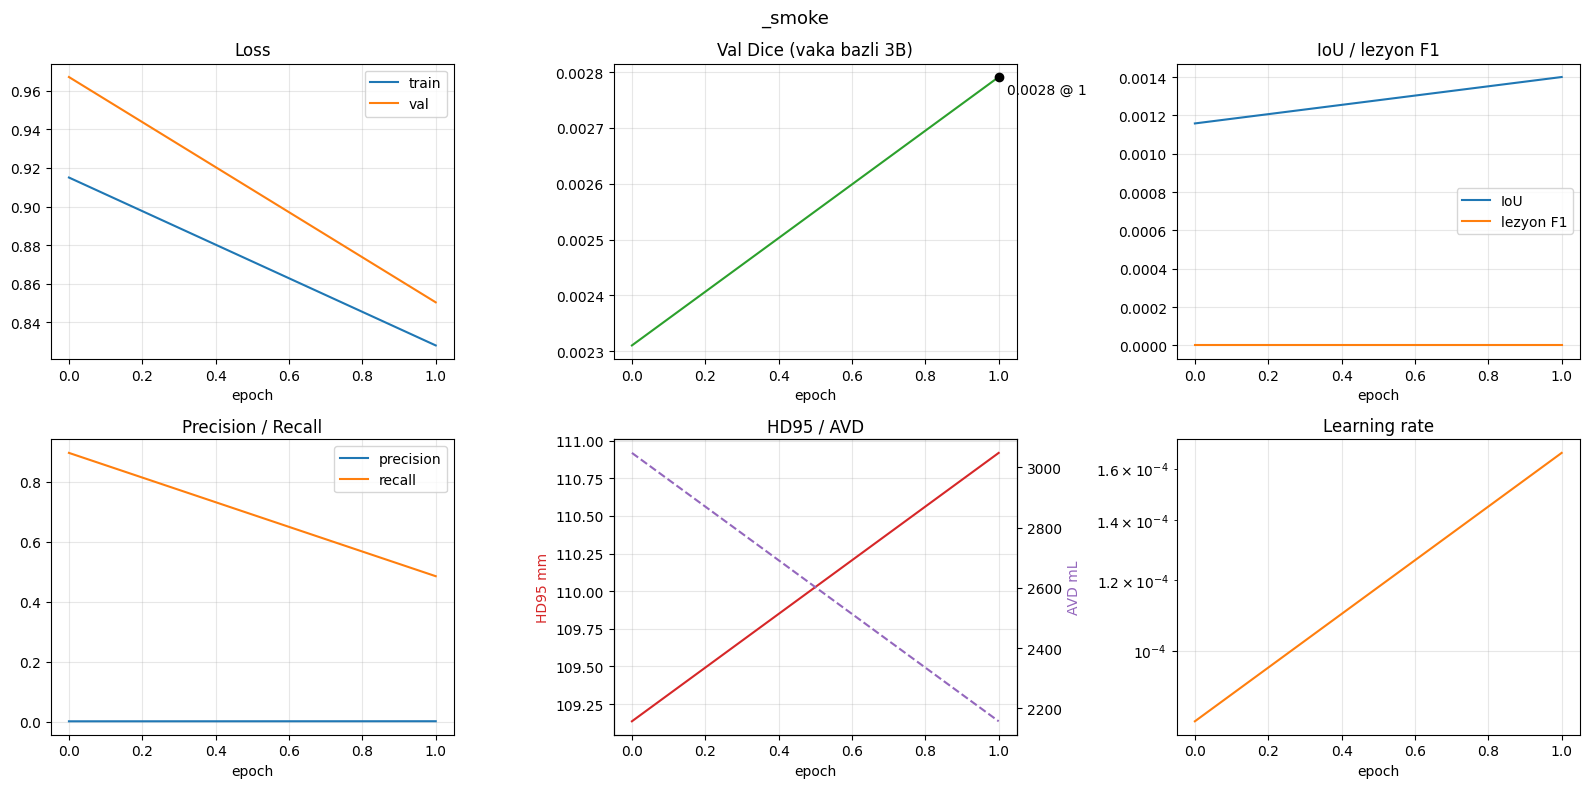

In [21]:
# 2 epoch gercek egitim - taban cizgisi mimarisi, kucuk alt kume
SMOKE = '_smoke'
MODEL_CONFIGS[SMOKE] = dict(MODEL_CONFIGS['unet_r34_2d'])
model, bd = egit(SMOKE, max_epochs=2, train_vakalar=kucuk_tr, val_vakalar=kucuk_va)

log = pd.read_excel(os.path.join(PROJE, SMOKE, f'{SMOKE}_log.xlsx'))
print('\nlog kolonlari:', list(log.columns))
bos_kolon = [k for k in SCHEMA if log[k].isna().any()]
assert not bos_kolon, f'bos kalan kolon: {bos_kolon}'
assert np.isfinite(log.train_loss).all(), 'train_loss sonlu degil'
print('13/13 kolon dolu, kayiplar sonlu')
print(log.to_string(index=False))

resume: epoch 2 den devam, best_dice=0.0028
_smoke | 24.43 M parametre | 338 egitim dilim (169 lezyonlu) | 10 adim/epoch | 3 val vakasi
ep   2 | train 0.7459 | val 0.7683 | dice 0.0111 * | iou 0.0056 | hd95 105.95 | avd 399.74 | lezF1 0.001 | lr 2.50e-04 | 230 sn
ep   3 | train 0.6909 | val 0.7209 | dice 0.0179 * | iou 0.0092 | hd95 104.59 | avd 162.87 | lezF1 0.006 | lr 2.50e-04 | 303 sn

resume sonrasi epoch listesi: [0, 1, 2, 3] -> tekrar yok
smoke artefaktlari temizlendi

PARCA 4 TAMAM - Parca 5 (taban cizgisi tam egitim) baslatilabilir.


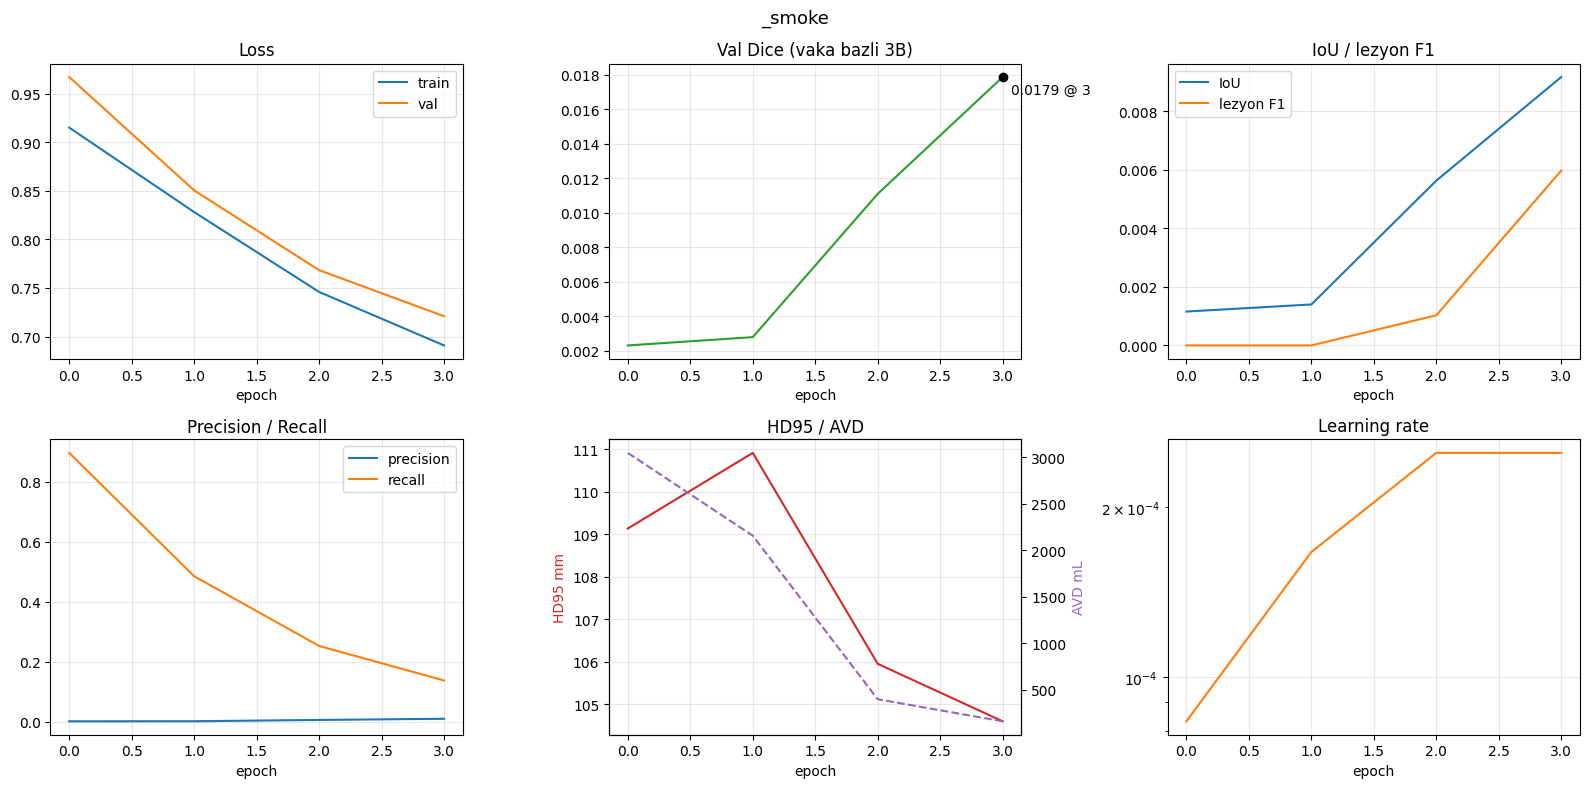

In [22]:
# Resume: 2 epoch daha, epoch 2'den devam etmeli ve satir tekrari olmamali
model2, bd2 = egit(SMOKE, resume=True, max_epochs=4,
                   train_vakalar=kucuk_tr, val_vakalar=kucuk_va)
log2 = pd.read_excel(os.path.join(PROJE, SMOKE, f'{SMOKE}_log.xlsx'))
assert len(log2) == 4 and not log2.epoch.duplicated().any(), log2.epoch.tolist()
print('\nresume sonrasi epoch listesi:', log2.epoch.tolist(), '-> tekrar yok')

import shutil as _sh
_sh.rmtree(os.path.join(PROJE, SMOKE), ignore_errors=True)
_sh.rmtree(os.path.join(YEREL, SMOKE), ignore_errors=True)
MODEL_CONFIGS.pop(SMOKE, None)
print('smoke artefaktlari temizlendi')
print()
print('PARCA 4 TAMAM - Parca 5 (taban cizgisi tam egitim) baslatilabilir.')

---

# Parca 5-6 - Egitim kosulari

`MODEL_KEY` degistirilip bu bolum yeniden calistirilir. Her kosu kendi
`<MODEL_KEY>/` klasorune yazar; hicbir sey uzerine binmez.

**Sira** (`PLAN.md` Bolum 4): `unet_r34_2d` (taban cizgisi) -> `unet_r34_25d` ->
`segformer_b0` -> `unet_mbv3` -> `unet3d_patch` -> `A1_flair` -> `A2_tversky` ->
`A3_k1` -> `A3_k3`.

**Oturum koparsa**: `RESUME = True` yapip ayni hucreyi calistir. `last.pt` bulunur,
epoch+1'den devam edilir, Excel'de tekrar satir olusmaz.

In [23]:
MODEL_KEY = 'A1_flair'      # <-- kosulacak model
RESUME = False                 # <-- oturum koptuysa True

c = konfig(MODEL_KEY)
print(f"{MODEL_KEY}: {c['mimari']} / {c['encoder']} | k={c['k']} kanal={c['kanal']} "
      f"batch={c['batch']} loss={c['loss']}")
print(f"max_epochs={c['max_epochs']} patience={c['patience']} warmup={c['warmup_epochs']}")
print(f"train {len(SPLIT['train'])} / val {len(SPLIT['val'])} / test {len(SPLIT['test'])} vaka")

A1_flair: unet / resnet34 | k=2 kanal=15 batch=32 loss=dice_bce
max_epochs=70 patience=15 warmup=3
train 161 / val 39 / test 50 vaka


A1_flair | 24.47 M parametre | 7602 egitim dilim (3801 lezyonlu) | 237 adim/epoch | 39 val vakasi
ep   0 | train 0.7097 | val 0.6300 | dice 0.1944 * | iou 0.1243 | hd95  63.48 | avd  64.60 | lezF1 0.022 | lr 8.33e-05 | 70 sn


/tmp/ipykernel_76019/4229486145.py:15: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  df = pd.concat([df, pd.DataFrame([{k: satir.get(k, np.nan) for k in SCHEMA}])], ignore_index=True)


ep   1 | train 0.5374 | val 0.5080 | dice 0.4469 * | iou 0.3252 | hd95  51.86 | avd  11.07 | lezF1 0.105 | lr 1.67e-04 | 55 sn
ep   2 | train 0.4443 | val 0.4637 | dice 0.3866   | iou 0.2754 | hd95  65.06 | avd  17.77 | lezF1 0.114 | lr 2.50e-04 | 77 sn
ep   3 | train 0.3951 | val 0.4195 | dice 0.4744 * | iou 0.3544 | hd95  59.38 | avd   8.54 | lezF1 0.120 | lr 2.50e-04 | 96 sn
ep   4 | train 0.2985 | val 0.2377 | dice 0.5322 * | iou 0.3983 | hd95  44.17 | avd   8.24 | lezF1 0.240 | lr 2.50e-04 | 100 sn
ep   5 | train 0.1817 | val 0.1139 | dice 0.5662 * | iou 0.4393 | hd95  23.29 | avd   8.08 | lezF1 0.329 | lr 2.50e-04 | 103 sn
ep   6 | train 0.1356 | val 0.0915 | dice 0.5936 * | iou 0.4634 | hd95  19.22 | avd   6.73 | lezF1 0.390 | lr 2.50e-04 | 84 sn
ep   7 | train 0.1244 | val 0.0936 | dice 0.5637   | iou 0.4384 | hd95  15.76 | avd   8.16 | lezF1 0.412 | lr 2.50e-04 | 75 sn
ep   8 | train 0.1180 | val 0.0866 | dice 0.6108 * | iou 0.4808 | hd95  18.23 | avd   5.68 | lezF1 0.418 | lr

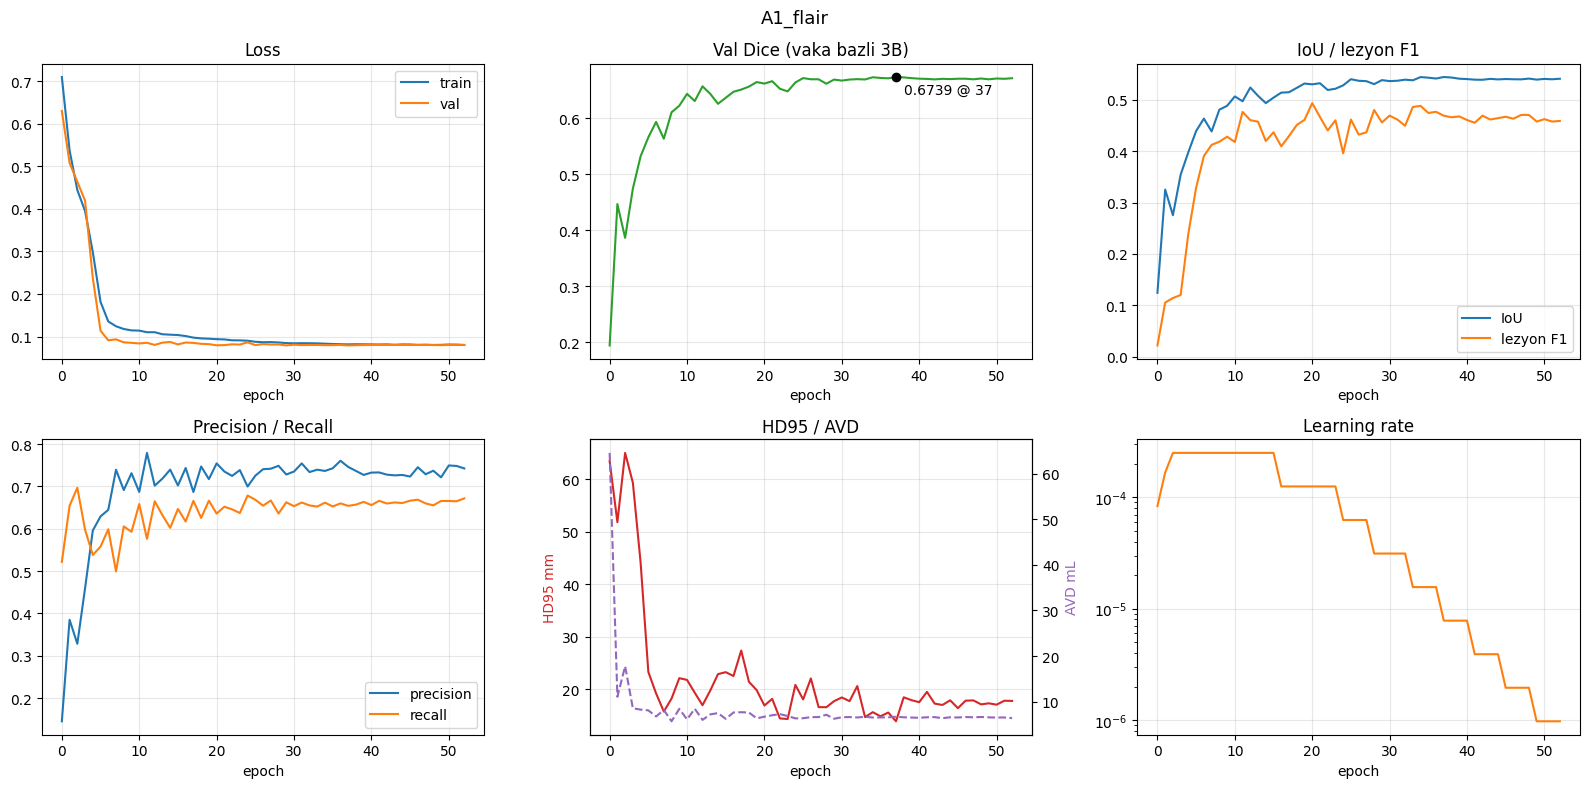

In [24]:
t_bas = time.time()
model, best_dice = egit(MODEL_KEY, resume=RESUME)
print(f'\n{MODEL_KEY} bitti | en iyi val Dice {best_dice:.4f} | '
      f'toplam {(time.time()-t_bas)/60:.1f} dk')

## Test degerlendirmesi

`best.pt` ile 50 test vakasi. **Vaka basina** metrikler ayri dosyaya yaziliyor
(`test_tahminler.xlsx`) - Parca 7'deki eslestirilmis Wilcoxon karsilastirmasi bunu okuyacak,
ozet ortalamalar yeterli degil.

Kirilimlar: hacim tertili (Bolum 5 zorunlu kildi) ve merkez.

In [25]:
kok = os.path.join(PROJE, MODEL_KEY)
yol, durum = find_resumable_checkpoint(kok)
best_yol = os.path.join(kok, 'checkpoints', 'best.pt')
durum_best = torch.load(best_yol, map_location='cpu', weights_only=False)
model_test = model_yap(c).to(CIHAZ)
model_test.load_state_dict(durum_best['model'])
print(f"best.pt yuklendi: epoch {durum_best['epoch']} val Dice {durum_best['best_dice']:.4f}")

veri_test = npy_yukle(SPLIT['test'], flair=c['flair'])
t0 = time.time()
_, vaka_m, test_loss = val_degerlendir(model_test, veri_test, SPLIT['test'], c, kayip_fn=loss_yap(c))
print(f'50 vaka {time.time()-t0:.0f} sn')

tst = pd.DataFrame(vaka_m)
tst.insert(0, 'vaka', SPLIT['test'])
# Tertil manifest'ten geliyor - 250 vaka uzerinden tanimli ve split de ona gore stratifiye
# edildi. Test icinde yeniden qcut yapmak her modelde ayni siniri vermez, karsilastirmayi bozar.
tst = tst.merge(MAN[['vaka', 'merkez', 'hacim_ml', 'lezyonlu_dilim', 'tertil']],
                on='vaka', how='left')
tst.to_excel(os.path.join(kok, f'{MODEL_KEY}_test_tahminler.xlsx'), index=False)

print('\n--- test ozeti ---')
for k in ['dice', 'iou', 'precision', 'recall', 'hd95', 'avd_ml', 'lezyon_f1']:
    print(f'  {k:10s} {np.nanmean(tst[k]):.4f} +- {np.nanstd(tst[k]):.4f}')
print('\n--- hacim tertiline gore ---')
print(tst.groupby('tertil', observed=True)[['dice', 'iou', 'recall', 'avd_ml', 'lezyon_f1']].mean().to_string())
print('\n--- merkeze gore ---')
print(tst.groupby('merkez')[['dice', 'iou', 'recall', 'avd_ml']].agg(['mean', 'count']).to_string())

best.pt yuklendi: epoch 37 val Dice 0.6739
50 vaka 14 sn

--- test ozeti ---
  dice       0.6568 +- 0.2347
  iou        0.5264 +- 0.2174
  precision  0.7245 +- 0.2457
  recall     0.6488 +- 0.2458
  hd95       18.0303 +- 19.7555
  avd_ml     4.2667 +- 6.8657
  lezyon_f1  0.4557 +- 0.2362

--- hacim tertiline gore ---
            dice       iou    recall    avd_ml  lezyon_f1
tertil                                                   
buyuk   0.810677  0.686513  0.784183  7.284706   0.421026
kucuk   0.538712  0.403674  0.535056  0.419500   0.452317
orta    0.614047  0.481890  0.620610  4.869647   0.493486

--- merkeze gore ---
            dice             iou          recall          avd_ml      
            mean count      mean count      mean count      mean count
merkez                                                                
1       0.637200    39  0.506888    39  0.613588    39  3.635692    39
2       0.726261    11  0.595728    11  0.773859    11  6.504000    11


In [26]:
ozet_satir = dict(
    model_key=MODEL_KEY, mimari=c['mimari'], encoder=str(c['encoder']),
    k=c['k'], kanal=c['kanal'], batch=c['batch'], loss=c['loss'],
    parametre=parametre_sayisi(model_test),
    en_iyi_epoch=int(durum_best['epoch']), val_dice=float(durum_best['best_dice']),
    test_loss=test_loss,
    test_dice=float(np.nanmean(tst.dice)), test_dice_std=float(np.nanstd(tst.dice)),
    test_dice_sem=float(np.nanstd(tst.dice) / np.sqrt(len(tst))),
    test_iou=float(np.nanmean(tst.iou)),
    test_precision=float(np.nanmean(tst.precision)), test_recall=float(np.nanmean(tst.recall)),
    test_hd95=float(np.nanmean(tst.hd95)), test_avd_ml=float(np.nanmean(tst.avd_ml)),
    test_lezyon_f1=float(np.nanmean(tst.lezyon_f1)),
    test_lezyon_sayi_fark=float(np.nanmean(tst.lezyon_sayi_fark)),
    dice_kucuk=float(tst[tst.tertil == 'kucuk'].dice.mean()),
    dice_orta=float(tst[tst.tertil == 'orta'].dice.mean()),
    dice_buyuk=float(tst[tst.tertil == 'buyuk'].dice.mean()),
    esik=c['esik'],
)
pd.DataFrame([ozet_satir]).to_excel(os.path.join(kok, f'{MODEL_KEY}_test_summary.xlsx'), index=False)
for k, v in ozet_satir.items():
    print(f'{k:22s} {v}')

model_key              A1_flair
mimari                 unet
encoder                resnet34
k                      2
kanal                  15
batch                  32
loss                   dice_bce
parametre              24474001
en_iyi_epoch           37
val_dice               0.6738583136814165
test_loss              0.07506236333518346
test_dice              0.6567936161028838
test_dice_std          0.23466113029337393
test_dice_sem          0.03318609530226894
test_iou               0.5264327352265347
test_precision         0.7244522452419142
test_recall            0.6488474598678112
test_hd95              18.03031789165571
test_avd_ml            4.266719999999999
test_lezyon_f1         0.4556752464241866
test_lezyon_sayi_fark  5.16
dice_kucuk             0.538711576446169
dice_orta              0.6140465639158661
dice_buyuk             0.8106767056138685
esik                   0.5


## Sabit vaka gorselleri

`eval_cases.json` - tum modellerde ayni 5 vaka, hacim araligina yayilmis. Her vakada
lezyonun en yogun oldugu dilim gosteriliyor.

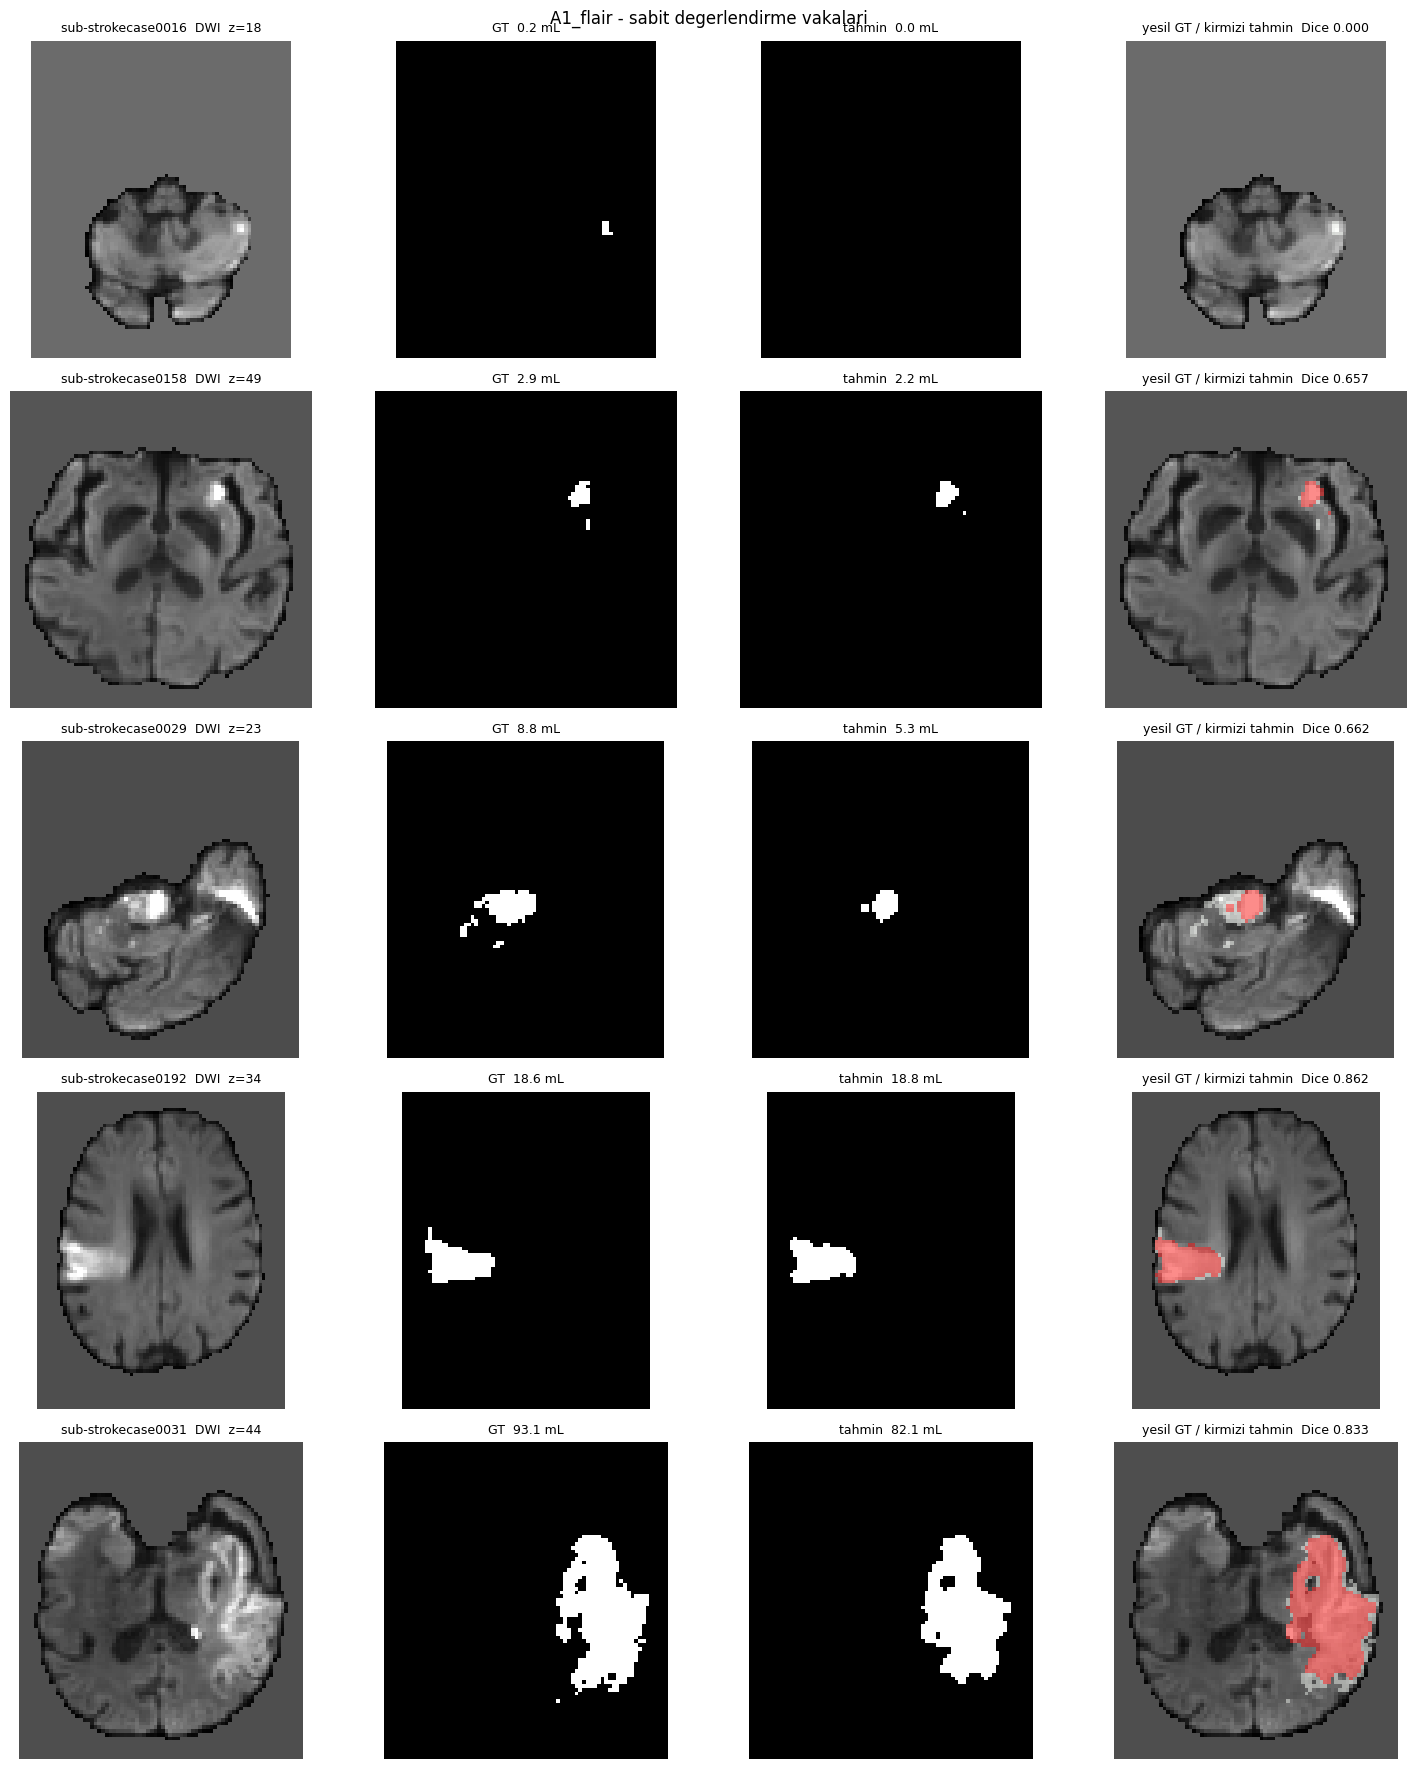


yazildi: /content/drive/MyDrive/iskemik_inme/A1_flair
   A1_flair_cases
   A1_flair_curves.png
   A1_flair_log.xlsx
   A1_flair_test_summary.xlsx
   A1_flair_test_tahminler.xlsx
   checkpoints

A1_flair TAMAM. Sonraki model icin MODEL_KEY degistirip Parca 5 bolumunu tekrar calistir.


In [27]:
vaka_dir = os.path.join(kok, f'{MODEL_KEY}_cases')
os.makedirs(vaka_dir, exist_ok=True)

fig, ax = plt.subplots(len(EVAL_CASES), 4, figsize=(15, 3.6 * len(EVAL_CASES)))
for i, v in enumerate(EVAL_CASES):
    tahmin, gt, _ = vaka_tahmin(model_test, veri_test, v, c)
    m = vaka_metrikleri(tahmin, gt)
    x = veri_test[v]['x']
    z = int(np.argmax(gt.sum(axis=(0, 1)))) if gt.any() else gt.shape[2] // 2
    dwi = x[0, :, :, z].astype(np.float32)
    hac = float(MAN.loc[MAN.vaka == v, 'hacim_ml'].iloc[0])

    ax[i, 0].imshow(dwi.T, cmap='gray', origin='lower')
    ax[i, 0].set_title(f'{v}  DWI  z={z}', fontsize=9)
    ax[i, 1].imshow(gt[:, :, z].T, cmap='gray', origin='lower')
    ax[i, 1].set_title(f'GT  {hac:.1f} mL', fontsize=9)
    ax[i, 2].imshow(tahmin[:, :, z].T, cmap='gray', origin='lower')
    ax[i, 2].set_title(f'tahmin  {m["hacim_tahmin_ml"]:.1f} mL', fontsize=9)
    ax[i, 3].imshow(dwi.T, cmap='gray', origin='lower')
    ax[i, 3].imshow(np.ma.masked_where(~gt[:, :, z].T, gt[:, :, z].T), cmap='Greens', alpha=.45, origin='lower')
    ax[i, 3].imshow(np.ma.masked_where(~tahmin[:, :, z].T, tahmin[:, :, z].T), cmap='autumn', alpha=.45, origin='lower')
    ax[i, 3].set_title(f'yesil GT / kirmizi tahmin  Dice {m["dice"]:.3f}', fontsize=9)
    for j in range(4):
        ax[i, j].set_axis_off()

fig.suptitle(f'{MODEL_KEY} - sabit degerlendirme vakalari', fontsize=12)
plt.tight_layout()
plt.savefig(os.path.join(vaka_dir, f'{MODEL_KEY}_cases.png'), dpi=130, bbox_inches='tight')
plt.show()

mirror_to_local(MODEL_KEY)
print('\nyazildi:', kok)
for f in sorted(os.listdir(kok)):
    print('  ', f)
print(f'\n{MODEL_KEY} TAMAM. Sonraki model icin MODEL_KEY degistirip Parca 5 bolumunu tekrar calistir.')

## Ara karsilastirma (biten kosular)

Her kosudan sonra calistirilabilir. Vaka basina test Dice'lari uzerinden **eslestirilmis**
Wilcoxon: 50 vakalik test setinde ciplak ortalama farki tek basina bir sey soylemez.
Nihai istatistik Parca 7'de (bootstrap CI + coklu karsilastirma duzeltmesi).

In [28]:
from scipy import stats

TABAN = 'unet_r34_2d'
bitenler = [k for k in MODEL_CONFIGS
            if os.path.exists(os.path.join(PROJE, k, f'{k}_test_summary.xlsx'))]
print('biten kosu:', bitenler)

ozet = pd.concat([pd.read_excel(os.path.join(PROJE, k, f'{k}_test_summary.xlsx'))
                  for k in bitenler], ignore_index=True).sort_values('test_dice', ascending=False)
kolon = ['model_key', 'parametre', 'en_iyi_epoch', 'val_dice', 'test_dice', 'test_dice_sem',
         'test_iou', 'test_precision', 'test_recall', 'test_hd95', 'test_avd_ml',
         'test_lezyon_f1', 'dice_kucuk', 'dice_orta', 'dice_buyuk']
print()
print(ozet[kolon].to_string(index=False, float_format=lambda v: f'{v:.4f}'))
ozet.to_excel(os.path.join(PROJE, 'karsilastirma_tablosu.xlsx'), index=False)

biten kosu: ['unet_r34_2d', 'unet_r34_25d', 'segformer_b0', 'unet_mbv3', 'unet3d', 'A1_flair', 'A2_tversky', 'A3_k1', 'A3_k3']

   model_key  parametre  en_iyi_epoch  val_dice  test_dice  test_dice_sem  test_iou  test_precision  test_recall  test_hd95  test_avd_ml  test_lezyon_f1  dice_kucuk  dice_orta  dice_buyuk
      unet3d    1400993            35    0.7081     0.7023         0.0327    0.5787          0.6886       0.7562    16.5821       3.7646          0.5698      0.5541     0.7111      0.8330
 unet_r34_2d   24433233            36    0.6777     0.6965         0.0270    0.5616          0.7540       0.6844    16.0582       2.8405          0.5717      0.5638     0.6953      0.8226
       A3_k1   24445777            35    0.6982     0.6896         0.0294    0.5575          0.7491       0.6796    16.7960       2.3954          0.5219      0.5353     0.6958      0.8286
  A2_tversky   24458321            55    0.6845     0.6806         0.0295    0.5464          0.6741       0.7188    16.7

In [29]:
# Eslestirilmis karsilastirma: her model vs taban cizgisi, ayni 50 vaka
vaka_dice = {}
for k in bitenler:
    d = pd.read_excel(os.path.join(PROJE, k, f'{k}_test_tahminler.xlsx'))
    vaka_dice[k] = d.set_index('vaka').dice

if TABAN in vaka_dice and len(bitenler) > 1:
    taban = vaka_dice[TABAN]
    print(f'{"model":16s} {"fark":>8s} {"kazandi":>8s} {"kaybetti":>9s} {"Wilcoxon p":>11s}')
    for k in bitenler:
        if k == TABAN:
            continue
        ortak = taban.index.intersection(vaka_dice[k].index)
        a, b = taban[ortak], vaka_dice[k][ortak]
        fark = float((b - a).mean())
        p = stats.wilcoxon(b, a).pvalue
        print(f'{k:16s} {fark:+8.4f} {int((b>a).sum()):8d} {int((b<a).sum()):9d} {p:11.4f}'
              + ('  <- anlamli' if p < 0.05 else ''))
    print()
    print(f'Not: {len(ortak)} vaka, coklu karsilastirma duzeltmesi YOK - Parca 7 uygulayacak.')
else:
    print('Karsilastirma icin taban cizgisi ve en az bir kosu daha gerekli.')

model                fark  kazandi  kaybetti  Wilcoxon p
unet_r34_25d      -0.0313       17        32      0.0249  <- anlamli
segformer_b0      -0.0567        6        43      0.0000  <- anlamli
unet_mbv3         -0.0221       13        36      0.0048  <- anlamli
unet3d            +0.0058       30        19      0.0844
A1_flair          -0.0397       11        38      0.0011  <- anlamli
A2_tversky        -0.0159       20        29      0.1714
A3_k1             -0.0069       26        23      0.6652
A3_k3             -0.0169       20        29      0.0844

Not: 50 vaka, coklu karsilastirma duzeltmesi YOK - Parca 7 uygulayacak.


---

# Parca 7 - Degerlendirme

Dokuz kosu bitti. Bu bolum `PLAN.md` Bolum 5'te acik birakilan uc karari kapatiyor ve
istatistigi resmilestiriyor.

| Is | Nerede secilir | Nerede uygulanir |
|---|---|---|
| Esik (simdiye kadar sabit 0,5) | **val (39 vaka)** | test, tek sefer |
| Kucuk bilesen eleme esigi | **val** | test, tek sefer |
| Bootstrap CI | test | - |
| Lezyon F1 tanim dogrulamasi | test | - |

**Esik ve bilesen esigi TEST'te taranmayacak.** Test uzerinde taramak, 50 vakalik sete
uydurmak olur ve raporlanan sayilari iyimser yapar. Bu ayrim raporda da yazilacak.

In [1]:
from scipy import stats

DEG_DIR = os.path.join(PROJE, 'degerlendirme')
os.makedirs(DEG_DIR, exist_ok=True)

TABAN = 'unet_r34_2d'
# Esik/bilesen taramasi yalniz aday modellerde: taban cizgisi + nominal en iyi.
# Parca 8 merdiveni de bu ikisi uzerinde kosacak (Bolum 5m).
ADAYLAR = ['unet3d', 'unet_r34_2d']

BITENLER = [k for k in MODEL_CONFIGS
            if os.path.exists(os.path.join(PROJE, k, f'{k}_test_summary.xlsx'))]
print('biten kosu:', len(BITENLER))
print('adaylar (esik taramasi):', ADAYLAR)
print('cikti:', DEG_DIR)

NameError: name 'os' is not defined

In [ ]:
def model_yukle(model_key):
    c = konfig(model_key)
    durum = torch.load(os.path.join(PROJE, model_key, 'checkpoints', 'best.pt'),
                       map_location='cpu', weights_only=False)
    m = model_yap(c).to(CIHAZ)
    m.load_state_dict(durum['model'])
    m.eval()
    return m, c, durum


@torch.no_grad()
def olasilik_hacmi(model, veri, vaka, c):
    '''vaka_tahmin ile ayni ileri gecis, ama esiklenmemis olasilik dondurur.
    Esik taramasi bunun uzerinde yapiliyor - her esik icin modeli tekrar kosmaya gerek yok.'''
    x = veri[vaka]['x']
    h, w, D = x.shape[1], x.shape[2], x.shape[3]

    if c['mimari'] == 'unet3d':
        xt = torch.from_numpy(hacim_dolgula(x.astype(np.float32)))[None].to(CIHAZ)
        with torch.amp.autocast('cuda', enabled=(c['amp'] and CIHAZ == 'cuda')):
            logit = model(xt)
        p = torch.sigmoid(logit.float())[0, 0].cpu().numpy()
        o = hacim_ofset((h, w, D))
        return p[o[0]:o[0]+h, o[1]:o[1]+w, o[2]:o[2]+D].astype(np.float16)

    k = c['k'] or 0
    yigin = []
    for z in range(D):
        zs = np.clip(np.arange(z - k, z + k + 1), 0, D - 1)
        img = x[:, :, :, zs].astype(np.float32).transpose(1, 2, 0, 3).reshape(h, w, -1)
        yigin.append(dolgula(img.transpose(2, 0, 1)))
    t = torch.from_numpy(np.stack(yigin)).to(CIHAZ)
    cikti = []
    for i in range(0, len(t), c['batch']):
        with torch.amp.autocast('cuda', enabled=(c['amp'] and CIHAZ == 'cuda')):
            cikti.append(torch.sigmoid(model(t[i:i+c['batch']]).float()).cpu())
    p = torch.cat(cikti)[:, 0].numpy()
    ust, sol = (H_HEDEF - h) // 2, (W_HEDEF - w) // 2
    return p[:, ust:ust+h, sol:sol+w].transpose(1, 2, 0).astype(np.float16)


OLASILIK = {}     # (model_key, bolum) -> {vaka: olasilik hacmi}
GT = {}
t0 = time.time()
for mk in ADAYLAR:
    m, c, _ = model_yukle(mk)
    for bolum in ('val', 'test'):
        veri = npy_yukle(SPLIT[bolum], flair=c['flair'])
        OLASILIK[(mk, bolum)] = {v: olasilik_hacmi(m, veri, v, c) for v in SPLIT[bolum]}
        if bolum not in GT:
            GT[bolum] = {v: veri[v]['y'].astype(bool) for v in SPLIT[bolum]}
    del m
    if CIHAZ == 'cuda':
        torch.cuda.empty_cache()
    print(f'{mk}: olasilik haritalari hazir ({time.time()-t0:.0f} sn)')

unet3d: olasilik haritalari hazir (11 sn)
unet_r34_2d: olasilik haritalari hazir (53 sn)


## 7.1 Esik taramasi - **val uzerinde**

Simdiye kadar butun kosular sabit 0,5 esigi kullandi. `unet3d`'nin asiri segmentasyon egilimi
(recall 0,756 / precision 0,689, AVD 3,76 mL - Bolum 5f) esigin optimal olmayabilecegini
dusundurdu. Taranan aralik 0,10-0,90.

In [ ]:
def bilesen_ele(maske, min_voxel):
    '''min_voxel altindaki bagli bilesenleri siler.'''
    if min_voxel <= 0:
        return maske
    et, n = ndimage.label(maske, BAGLANTI)
    if n == 0:
        return maske
    boyut = np.bincount(et.ravel())
    kucuk = np.where(boyut < min_voxel)[0]
    return maske & ~np.isin(et, kucuk[kucuk > 0])


def tara(mk, bolum, esikler, min_voxel=0):
    satir = []
    for e in esikler:
        m = []
        for v in SPLIT[bolum]:
            tah = OLASILIK[(mk, bolum)][v].astype(np.float32) >= e
            if min_voxel:
                tah = bilesen_ele(tah, min_voxel)
            m.append(vaka_metrikleri(tah, GT[bolum][v]))
        o = topla(m)
        satir.append(dict(esik=e, min_voxel=min_voxel, **{k: o[k] for k in
                     ('dice', 'iou', 'precision', 'recall', 'hd95', 'avd_ml', 'lezyon_f1')}))
    return pd.DataFrame(satir)


ESIKLER = np.round(np.arange(0.10, 0.91, 0.05), 2)
esik_tablo = {}
for mk in ADAYLAR:
    d = tara(mk, 'val', ESIKLER)
    esik_tablo[mk] = d
    en_iyi = d.loc[d.dice.idxmax()]
    print(f"\n--- {mk} (val) ---")
    print(d[['esik', 'dice', 'precision', 'recall', 'avd_ml', 'lezyon_f1']]
          .to_string(index=False, float_format=lambda v: f'{v:.4f}'))
    print(f"en iyi val Dice: esik={en_iyi.esik:.2f} -> {en_iyi.dice:.4f} "
          f"(0,50'de {d[d.esik == 0.50].dice.iloc[0]:.4f})")


--- unet3d (val) ---
  esik   dice  precision  recall  avd_ml  lezyon_f1
0.1000 0.6979     0.6810  0.7727  6.8396     0.5717
0.1500 0.7016     0.6931  0.7660  6.5668     0.5932
0.2000 0.7035     0.6996  0.7611  6.3895     0.5956
0.2500 0.7049     0.7055  0.7574  6.2576     0.6038
0.3000 0.7060     0.7096  0.7542  6.1906     0.6125
0.3500 0.7072     0.7153  0.7505  6.1424     0.6204
0.4000 0.7069     0.7189  0.7463  6.0974     0.6169
0.4500 0.7077     0.7219  0.7441  6.0583     0.6208
0.5000 0.7081     0.7260  0.7412  6.0261     0.6121
0.5500 0.7085     0.7291  0.7388  6.0103     0.6202
0.6000 0.7090     0.7320  0.7358  5.9969     0.6203
0.6500 0.7099     0.7349  0.7330  5.9883     0.6210
0.7000 0.7100     0.7389  0.7283  5.9881     0.6306
0.7500 0.7092     0.7417  0.7229  6.0293     0.6280
0.8000 0.7091     0.7480  0.7167  6.1565     0.6176
0.8500 0.7089     0.7531  0.7102  6.3454     0.6121
0.9000 0.7062     0.7617  0.6991  6.6367     0.6207
en iyi val Dice: esik=0.70 -> 0.7100 (0,50

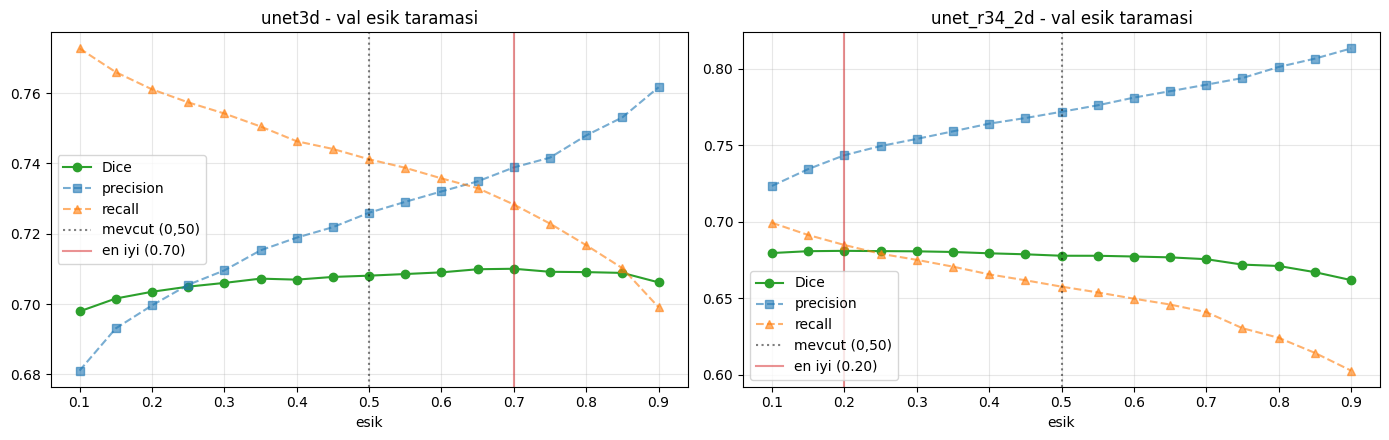

In [ ]:
fig, ax = plt.subplots(1, len(ADAYLAR), figsize=(7 * len(ADAYLAR), 4.5))
ax = np.atleast_1d(ax)
for i, mk in enumerate(ADAYLAR):
    d = esik_tablo[mk]
    a = ax[i]
    a.plot(d.esik, d.dice, 'o-', label='Dice', color='tab:green')
    a.plot(d.esik, d.precision, 's--', label='precision', alpha=.6)
    a.plot(d.esik, d.recall, '^--', label='recall', alpha=.6)
    a.axvline(0.5, color='k', ls=':', alpha=.5, label='mevcut (0,50)')
    e_iyi = d.loc[d.dice.idxmax(), 'esik']
    a.axvline(e_iyi, color='tab:red', ls='-', alpha=.5, label=f'en iyi ({e_iyi:.2f})')
    a.set_title(f'{mk} - val esik taramasi'); a.set_xlabel('esik'); a.grid(alpha=.3); a.legend()
plt.tight_layout()
plt.savefig(os.path.join(DEG_DIR, 'esik_taramasi.png'), dpi=130, bbox_inches='tight')
plt.show()

## 7.2 Kucuk bilesen eleme - **val uzerinde**

`PLAN.md` Bolum 2 karar 4: GT'de 897 adet 5-voxel alti bilesen var, dolayisiyla elemek yanlis
pozitifi dusururken recall ve lezyon F1'i de dusurebilir. Esik yukarida secildikten sonra
taraniyor.

In [ ]:
MIN_VOXELLER = [0, 5, 10, 20, 50]
SECIM = {}
bilesen_tablo = {}
for mk in ADAYLAR:
    e_iyi = float(esik_tablo[mk].loc[esik_tablo[mk].dice.idxmax(), 'esik'])
    d = pd.concat([tara(mk, 'val', [e_iyi], mv) for mv in MIN_VOXELLER], ignore_index=True)
    bilesen_tablo[mk] = d
    en_iyi = d.loc[d.dice.idxmax()]
    SECIM[mk] = dict(esik=e_iyi, min_voxel=int(en_iyi.min_voxel))
    print(f"\n--- {mk} (val, esik={e_iyi:.2f}) ---")
    print(d[['min_voxel', 'dice', 'precision', 'recall', 'avd_ml', 'lezyon_f1']]
          .to_string(index=False, float_format=lambda v: f'{v:.4f}'))
    print(f"secim: esik={e_iyi:.2f}, min_voxel={int(en_iyi.min_voxel)}")

with open(os.path.join(DEG_DIR, 'secim.json'), 'w') as f:
    json.dump(SECIM, f, indent=2)
print('\nsecim.json yazildi:', SECIM)


--- unet3d (val, esik=0.70) ---
 min_voxel   dice  precision  recall  avd_ml  lezyon_f1
         0 0.7100     0.7389  0.7283  5.9881     0.6306
         5 0.7099     0.7366  0.7273  5.9766     0.6299
        10 0.7094     0.7369  0.7257  5.9674     0.6058
        20 0.7002     0.7063  0.7171  5.9756     0.5329
        50 0.6711     0.6914  0.6755  5.9633     0.4332
secim: esik=0.70, min_voxel=0

--- unet_r34_2d (val, esik=0.20) ---
 min_voxel   dice  precision  recall  avd_ml  lezyon_f1
         0 0.6809     0.7434  0.6847  6.4285     0.4947
         5 0.6756     0.7443  0.6721  6.4392     0.5552
        10 0.6748     0.7501  0.6685  6.4677     0.5382
        20 0.6762     0.7635  0.6625  6.4745     0.5189
        50 0.6301     0.7137  0.6076  6.6018     0.4199
secim: esik=0.20, min_voxel=0

secim.json yazildi: {'unet3d': {'esik': 0.7, 'min_voxel': 0}, 'unet_r34_2d': {'esik': 0.2, 'min_voxel': 0}}


## 7.3 Secimin test'e uygulanmasi

Val'de secilen `(esik, min_voxel)` ciftinin test'teki etkisi. **Tek sefer uygulaniyor**;
test uzerinde hicbir arama yapilmadi.

In [ ]:
satir = []
test_vaka_m = {}
for mk in ADAYLAR:
    s = SECIM[mk]
    for ad, e, mv in [('once (0,50 / 0)', 0.5, 0), (f"sonra ({s['esik']:.2f} / {s['min_voxel']})",
                                                    s['esik'], s['min_voxel'])]:
        m = []
        for v in SPLIT['test']:
            tah = OLASILIK[(mk, 'test')][v].astype(np.float32) >= e
            if mv:
                tah = bilesen_ele(tah, mv)
            m.append(dict(vaka=v, **vaka_metrikleri(tah, GT['test'][v])))
        o = topla(m)
        satir.append(dict(model=mk, ayar=ad, **{k: o[k] for k in
                     ('dice', 'iou', 'precision', 'recall', 'hd95', 'avd_ml', 'lezyon_f1')}))
        if ad.startswith('sonra'):
            test_vaka_m[mk] = pd.DataFrame(m)

son = pd.DataFrame(satir)
print(son.to_string(index=False, float_format=lambda v: f'{v:.4f}'))
son.to_excel(os.path.join(DEG_DIR, 'esik_bilesen_etkisi.xlsx'), index=False)

      model             ayar   dice    iou  precision  recall    hd95  avd_ml  lezyon_f1
     unet3d  once (0,50 / 0) 0.7023 0.5787     0.6886  0.7562 16.5821  3.7646     0.5698
     unet3d sonra (0.70 / 0) 0.7063 0.5835     0.7098  0.7421 15.8338  3.2302     0.5811
unet_r34_2d  once (0,50 / 0) 0.6965 0.5616     0.7540  0.6844 16.0582  2.8406     0.5717
unet_r34_2d sonra (0.20 / 0) 0.6957 0.5606     0.7203  0.7122 17.7509  2.8086     0.5497


## 7.4 Bootstrap guven araliklari

50 vakalik test seti kucuk. Vaka duzeyinde 10.000 yeniden ornekleme ile persentil CI.
Modeller arasi fark icin **eslestirilmis** bootstrap (ayni vaka indeksleri iki modelde de).

In [ ]:
B = 10000
rng_b = np.random.default_rng(42)

vaka_dice = {}
for mk in BITENLER:
    d = pd.read_excel(os.path.join(PROJE, mk, f'{mk}_test_tahminler.xlsx'))
    vaka_dice[mk] = d.set_index('vaka').dice.reindex(SPLIT['test']).values

n = len(SPLIT['test'])
idx = rng_b.integers(0, n, size=(B, n))          # tum modellerde AYNI indeksler -> eslestirilmis

def ci(dizi):
    orn = dizi[idx].mean(axis=1)
    return np.percentile(orn, [2.5, 97.5])

satir = []
taban_d = vaka_dice[TABAN]
for mk in BITENLER:
    d = vaka_dice[mk]
    lo, hi = ci(d)
    if mk == TABAN:
        fark_lo = fark_hi = np.nan
        p = np.nan
    else:
        fark = (d - taban_d)
        fark_lo, fark_hi = ci(fark)
        p = stats.wilcoxon(d, taban_d).pvalue
    satir.append(dict(model=mk, dice=d.mean(), ci_alt=lo, ci_ust=hi,
                      fark=np.nan if mk == TABAN else float((d - taban_d).mean()),
                      fark_ci_alt=fark_lo, fark_ci_ust=fark_hi, wilcoxon_p=p))

boot = pd.DataFrame(satir).sort_values('dice', ascending=False)

# Holm duzeltmesi
kars = boot[boot.model != TABAN].sort_values('wilcoxon_p').reset_index(drop=True)
m_k = len(kars)
red = True
holm = []
for i, r in kars.iterrows():
    esik = 0.05 / (m_k - i)
    if red and r.wilcoxon_p < esik:
        holm.append('ANLAMLI')
    else:
        red = False
        holm.append('anlamli degil')
kars['holm_esik'] = [0.05 / (m_k - i) for i in range(m_k)]
kars['holm'] = holm
boot = boot.merge(kars[['model', 'holm_esik', 'holm']], on='model', how='left')

print(boot.to_string(index=False, float_format=lambda v: f'{v:.4f}'))
boot.to_excel(os.path.join(DEG_DIR, 'bootstrap_ci.xlsx'), index=False)

       model   dice  ci_alt  ci_ust    fark  fark_ci_alt  fark_ci_ust  wilcoxon_p  holm_esik          holm
      unet3d 0.7023  0.6338  0.7609  0.0058      -0.0400       0.0458      0.0844     0.0167 anlamli degil
 unet_r34_2d 0.6965  0.6402  0.7453     NaN          NaN          NaN         NaN        NaN           NaN
       A3_k1 0.6896  0.6284  0.7428 -0.0069      -0.0336       0.0183      0.6652     0.0500 anlamli degil
  A2_tversky 0.6806  0.6188  0.7340 -0.0159      -0.0477       0.0140      0.1714     0.0250 anlamli degil
       A3_k3 0.6796  0.6205  0.7328 -0.0169      -0.0380       0.0031      0.0844     0.0125 anlamli degil
   unet_mbv3 0.6744  0.6139  0.7294 -0.0221      -0.0512       0.0060      0.0048     0.0083       ANLAMLI
unet_r34_25d 0.6652  0.5974  0.7242 -0.0313      -0.0657      -0.0024      0.0249     0.0100 anlamli degil
    A1_flair 0.6568  0.5889  0.7182 -0.0397      -0.0795      -0.0038      0.0011     0.0071       ANLAMLI
segformer_b0 0.6398  0.5765  0.6964 -

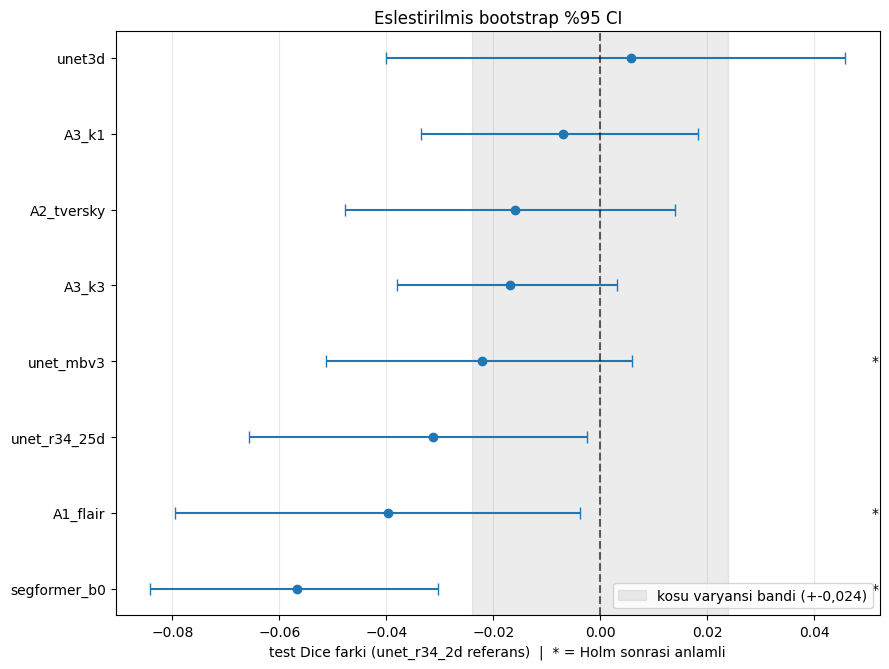

In [ ]:
# Forest plot: taban cizgisine gore fark + %95 CI
k = boot[boot.model != TABAN].sort_values('fark')
fig, a = plt.subplots(figsize=(9, 0.6 * len(k) + 2))
y = np.arange(len(k))
a.errorbar(k.fark, y, xerr=[k.fark - k.fark_ci_alt, k.fark_ci_ust - k.fark], fmt='o',
           capsize=4, color='tab:blue')
a.axvline(0, color='k', ls='--', alpha=.6)
a.axvspan(-0.024, 0.024, color='gray', alpha=.15, label='kosu varyansi bandi (+-0,024)')
a.set_yticks(y); a.set_yticklabels(k.model)
for i, (_, r) in enumerate(k.iterrows()):
    a.text(k.fark_ci_ust.max() + 0.005, i, ('*' if r.holm == 'ANLAMLI' else ''), va='center')
a.set_xlabel(f'test Dice farki ({TABAN} referans)  |  * = Holm sonrasi anlamli')
a.set_title('Eslestirilmis bootstrap %95 CI'); a.grid(alpha=.3, axis='x'); a.legend(loc='lower right')
plt.tight_layout()
plt.savefig(os.path.join(DEG_DIR, 'forest_dice.png'), dpi=130, bbox_inches='tight')
plt.show()

## 7.5 Lezyon F1 tanim dogrulamasi

Egitim dongusunde kendi hizli uygulamamiz kullanildi (IoU >= 0,1 ile bilesen eslestirme).
Burada iki sey kontrol ediliyor:

1. **IoU esigine duyarlilik** - sonuc esik secimine ne kadar bagli?
2. **`panoptica`** (ISLES'22'nin resmi araci) ile karsilastirma. Kurulamazsa ya da API
   uyusmazsa atlaniyor ve rapora "dogrulanamadi" diye yaziliyor - sessizce gecilmiyor.

In [ ]:
IOU_ESIKLER = [0.0001, 0.1, 0.25, 0.5]
mk = ADAYLAR[0]
s = SECIM[mk]
duyarlilik = []
for ie in IOU_ESIKLER:
    v_ = []
    for v in SPLIT['test']:
        tah = OLASILIK[(mk, 'test')][v].astype(np.float32) >= s['esik']
        if s['min_voxel']:
            tah = bilesen_ele(tah, s['min_voxel'])
        v_.append(lezyon_metrikleri(tah, GT['test'][v], iou_esik=ie)['lezyon_f1'])
    duyarlilik.append(dict(iou_esik=ie, lezyon_f1=float(np.mean(v_))))
duy = pd.DataFrame(duyarlilik)
print(f'--- {mk}: lezyon F1 - IoU esigine duyarlilik ---')
print(duy.to_string(index=False, float_format=lambda v: f'{v:.4f}'))
print(f'\naralik: {duy.lezyon_f1.max() - duy.lezyon_f1.min():.4f}')

--- unet3d: lezyon F1 - IoU esigine duyarlilik ---
 iou_esik  lezyon_f1
   0.0001     0.6088
   0.1000     0.5811
   0.2500     0.5274
   0.5000     0.3994

aralik: 0.2094


In [ ]:
PANOPTICA_OK = False
try:
    os.system('pip -q install panoptica')
    from panoptica import Panoptica_Evaluator, InputType
    # UNMATCHED_INSTANCE girdisi bir eslestirme algoritmasi ISTIYOR; verilmezse
    # "Got UnmatchedInstancePair but not InstanceMatchingAlgorithm" hatasi geliyor.
    # Esik bizim uygulamamizla ayni (0,1) olmali, yoksa karsilastirma anlamsiz.
    try:
        from panoptica.instance_matcher import NaiveThresholdMatching
    except ImportError:
        from panoptica import NaiveThresholdMatching
    ev = Panoptica_Evaluator(expected_input=InputType.UNMATCHED_INSTANCE,
                             instance_matcher=NaiveThresholdMatching(
                                 matching_threshold=LEZYON_IOU_ESIK))
    pan = []
    for v in SPLIT['test'][:10]:                    # 10 vaka - panoptica yavas
        tah = OLASILIK[(mk, 'test')][v].astype(np.float32) >= s['esik']
        if s['min_voxel']:
            tah = bilesen_ele(tah, s['min_voxel'])
        et_t = ndimage.label(tah, BAGLANTI)[0]
        et_g = ndimage.label(GT['test'][v], BAGLANTI)[0]
        r = ev.evaluate(et_t, et_g)['ungrouped']
        # panoptica'nin RQ'su (recognition quality) bizim lezyon F1'imizle ayni tanim:
        # 2TP / (2TP + FP + FN) bilesen duzeyinde.
        pan.append(dict(vaka=v, panoptica_rq=float(r.rq),
                        bizim=lezyon_metrikleri(tah, GT['test'][v])['lezyon_f1']))
    pn = pd.DataFrame(pan)
    korelasyon = pn.panoptica_rq.corr(pn.bizim)
    print(pn.to_string(index=False, float_format=lambda v: f'{v:.4f}'))
    print(f'\nortalama: panoptica {pn.panoptica_rq.mean():.4f} | bizim {pn.bizim.mean():.4f}'
          f' | korelasyon {korelasyon:.3f}')
    pn.to_excel(os.path.join(DEG_DIR, 'panoptica_karsilastirma.xlsx'), index=False)
    PANOPTICA_OK = True
except Exception as e:
    print('panoptica DOGRULAMASI YAPILAMADI:', repr(e)[:200])
    print('-> Rapora "lezyon F1 kendi uygulamamizla, panoptica ile capraz dogrulanmadi" yazilacak.')

────────────────────────────────────────── Thank you for using panoptica ──────────────────────────────────────────

Please support our development by citing

https://github.com/BrainLesion/panoptica#citation -- Thank you!

───────────────────────────────────────────────────────────────────────────────────────────────────────────────────

panoptica DOGRULAMASI YAPILAMADI: ValueError('Got UnmatchedInstancePair but not InstanceMatchingAlgorithm')
-> Rapora "lezyon F1 kendi uygulamamizla, panoptica ile capraz dogrulanmadi" yazilacak.


In [ ]:
ozet7 = dict(
    secim=SECIM,
    esik_val_kazanc={mk: float(esik_tablo[mk].dice.max() -
                               esik_tablo[mk][esik_tablo[mk].esik == 0.5].dice.iloc[0])
                     for mk in ADAYLAR},
    holm_anlamli=boot[boot.holm == 'ANLAMLI'].model.tolist(),
    en_iyi_test_dice=boot.iloc[0][['model', 'dice', 'ci_alt', 'ci_ust']].to_dict(),
    lezyon_f1_iou_duyarlilik=float(duy.lezyon_f1.max() - duy.lezyon_f1.min()),
    panoptica_dogrulandi=PANOPTICA_OK,
    kosu_varyans_bandi=0.024,
)
print(json.dumps(ozet7, indent=2, ensure_ascii=False, default=str))
with open(os.path.join(DEG_DIR, 'degerlendirme_ozeti.json'), 'w', encoding='utf-8') as f:
    json.dump(ozet7, f, indent=2, ensure_ascii=False, default=str)
for mk, d in test_vaka_m.items():
    d.to_excel(os.path.join(DEG_DIR, f'{mk}_test_secimli.xlsx'), index=False)
print('\nyazildi:', DEG_DIR)
for q in sorted(os.listdir(DEG_DIR)):
    print('  ', q)
print('\nPARCA 7 TAMAM.')

{
  "secim": {
    "unet3d": {
      "esik": 0.7,
      "min_voxel": 0
    },
    "unet_r34_2d": {
      "esik": 0.2,
      "min_voxel": 0
    }
  },
  "esik_val_kazanc": {
    "unet3d": 0.001968786985581339,
    "unet_r34_2d": 0.0032038472722016875
  },
  "holm_anlamli": [
    "unet_mbv3",
    "A1_flair",
    "segformer_b0"
  ],
  "en_iyi_test_dice": {
    "model": "unet3d",
    "dice": 0.7023322640479095,
    "ci_alt": 0.6337640366509997,
    "ci_ust": 0.7609121217818993
  },
  "lezyon_f1_iou_duyarlilik": 0.2093692344240552,
  "panoptica_dogrulandi": false,
  "kosu_varyans_bandi": 0.024
}

yazildi: /content/drive/MyDrive/iskemik_inme/degerlendirme
   bootstrap_ci.xlsx
   degerlendirme_ozeti.json
   esik_bilesen_etkisi.xlsx
   esik_taramasi.png
   forest_dice.png
   secim.json
   unet3d_test_secimli.xlsx
   unet_r34_2d_test_secimli.xlsx

PARCA 7 TAMAM.
